## NECESSARY LIBRARIES

In [1]:
# Core Data Processing and Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import joblib
import tempfile
import os

# Machine Learning - Preprocessing & Balancing
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict

# Machine Learning - Classical & Ensemble Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Deep Learning Framework (TensorFlow & Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, Input, Conv1D, MaxPooling1D, 
                                     GlobalMaxPooling1D, GlobalAveragePooling1D, 
                                     Flatten, Add, BatchNormalization, Activation, 
                                     GRU, LSTM)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report, 
    roc_auc_score, 
    roc_curve, 
    matthews_corrcoef,  # MCC: Gold standard for imbalanced datasets
    f1_score, 
    precision_score, 
    recall_score,
    average_precision_score,
    cohen_kappa_score   # Reliability metric
)

# Plotting Configuration (Standardized for Academic Reporting)
plt.style.use('ggplot')
warnings.filterwarnings('ignore') # Suppress unnecessary warnings

print("Libraries loaded successfully. Centralized import system ready.")

Libraries loaded successfully. Centralized import system ready.


## GLOBAL SETTINGS and UTILITY FUNCTIONS

In [2]:
# ==========================================
# Global modular utilities
# ==========================================

# File Paths
INPUT_FILE_PATH = r"C:\Users\halid\Desktop\DEHB deneme\Noise_STD_Fazla\adhd_data_realistic.csv"
# INPUT_FILE_PATH = r"C:\Users\halid\Desktop\DEHB deneme\Noise_STD_Fazla\adhd_data.csv"
OUTPUT_FILE_PATH = r"C:\Users\halid\Desktop\DEHB deneme\Noise_STD_Fazla\New_adhd_data.csv"

# Categorical Columns
BINARY_COLS = ['Gender']

# Global Result Storage
if 'model_results' not in globals():
    model_results = {}

if 'model_time_results' not in globals():
    model_time_results = {}

# Time Utilities
def format_time(seconds):
    if seconds < 1:
        return f"{seconds * 1000:.3f} ms"
    return f"{seconds:.4f} sec"

class TimeTracker:
    def __init__(self):
        self._starts = {}

    def start(self, key):
        self._starts[key] = time.perf_counter()

    def stop(self, key):
        return time.perf_counter() - self._starts[key]

timer = TimeTracker()

# Threshold Optimization
def optimize_threshold_cv(model, X, y, cv=5):
    cv_pred_proba = cross_val_predict(
        model, X, y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    thresholds = np.linspace(0.05, 0.95, 100)
    mcc_scores = [
        matthews_corrcoef(y, (cv_pred_proba >= t).astype(int))
        for t in thresholds
    ]

    best_idx = np.argmax(mcc_scores)
    return thresholds[best_idx], mcc_scores[best_idx]

# Inference Latency
def measure_inference_latency(model, X):

    if hasattr(X, 'toarray'):
        X = X.toarray()
    
    # Warm-up
    model.predict_proba(X[:5])

    start = time.perf_counter()
    for i in range(X.shape[0]):
        model.predict_proba(X[i:i+1])
    end = time.perf_counter()

    total = end - start
    latency_ms = (total / X.shape[0]) * 1000
    return total, latency_ms

# Metrics Computation
def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1_Score": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Kappa": cohen_kappa_score(y_true, y_pred),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "Confusion_Matrix": np.array([[tn, fp], [fn, tp]])
    }

# Metric Printing
def print_metrics(metrics, threshold):
    print(f"\n✓ Accuracy (Threshold {threshold:.2f}): {metrics['Accuracy']:.4f}")
    print(f"✓ F1-Score: {metrics['F1_Score']:.4f}")
    print(f"✓ ROC-AUC Score: {metrics['ROC_AUC']:.4f}")
    print(f"✓ PR-AUC Score:  {metrics['PR_AUC']:.4f}")
    print(f"✓ MCC Score:     {metrics['MCC']:.4f}")
    print(f"✓ Cohen's Kappa: {metrics['Kappa']:.4f}")
    print(f"✓ Specificity:   {metrics['Specificity']:.4f}")

# Confusion Matrix Plot
def plot_confusion_matrix(cm, model_name, threshold, cmap='Blues'):
    plt.figure(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No ADHD', 'ADHD']
    ).plot(cmap=plt.cm.get_cmap(cmap), values_format='d', ax=plt.gca())
    plt.title(f"{model_name} Confusion Matrix (Threshold {threshold:.2f})", fontsize=11)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# Model Size
def get_model_size_mb(model):
    tmp = "_tmp_model.pkl"
    joblib.dump(model, tmp)
    size = os.path.getsize(tmp) / (1024 * 1024)
    os.remove(tmp)
    return size

print("✅ Global settings, functions, and others")

✅ Global settings, functions, and others


DATA PREPARATION: EVIDENCE-BASED FEATURE SELECTION
✓ Dataset loaded: 6500 samples, 32 features

 Original Diagnosis_Class Distribution:
Diagnosis_Class
0    1575
1    1067
2    1253
3    2605
Name: count, dtype: int64

✓ Binary target created: ADHD_TARGET
  Class 0 (No ADHD): 1575
  Class 1 (ADHD):    4925
  Imbalance ratio:   3.13

  Dropping 'Difficulty_Organizing_Tasks' (redundant with Q1_5)
✓ Redundant feature removed

✓ Educational_Level encoded ordinally
  All categories successfully mapped (0 missing values)

✓ Gender corrected: [1,2] → [0,1]

 One-hot encoding: ['Family_History']
✓ Encoding completed

 DATA QUALITY:
  Missing values: 0
  Duplicates:     0
  Final shape: (6500, 32)

 TRAIN-TEST SPLIT:
  Train: 4550 samples (70.0%)
  Test:  1950 samples (30.0%)
  Features: 31
  Train class: {0: 1102, 1: 3448}
  Test class:  {0: 473, 1: 1477}

✓ Feature scaling completed (StandardScaler)

FEATURE IMPORTANCE ANALYSIS

 TOP 15 FEATURES (Mutual Information):
Feature  MI_Score
   Q1_5

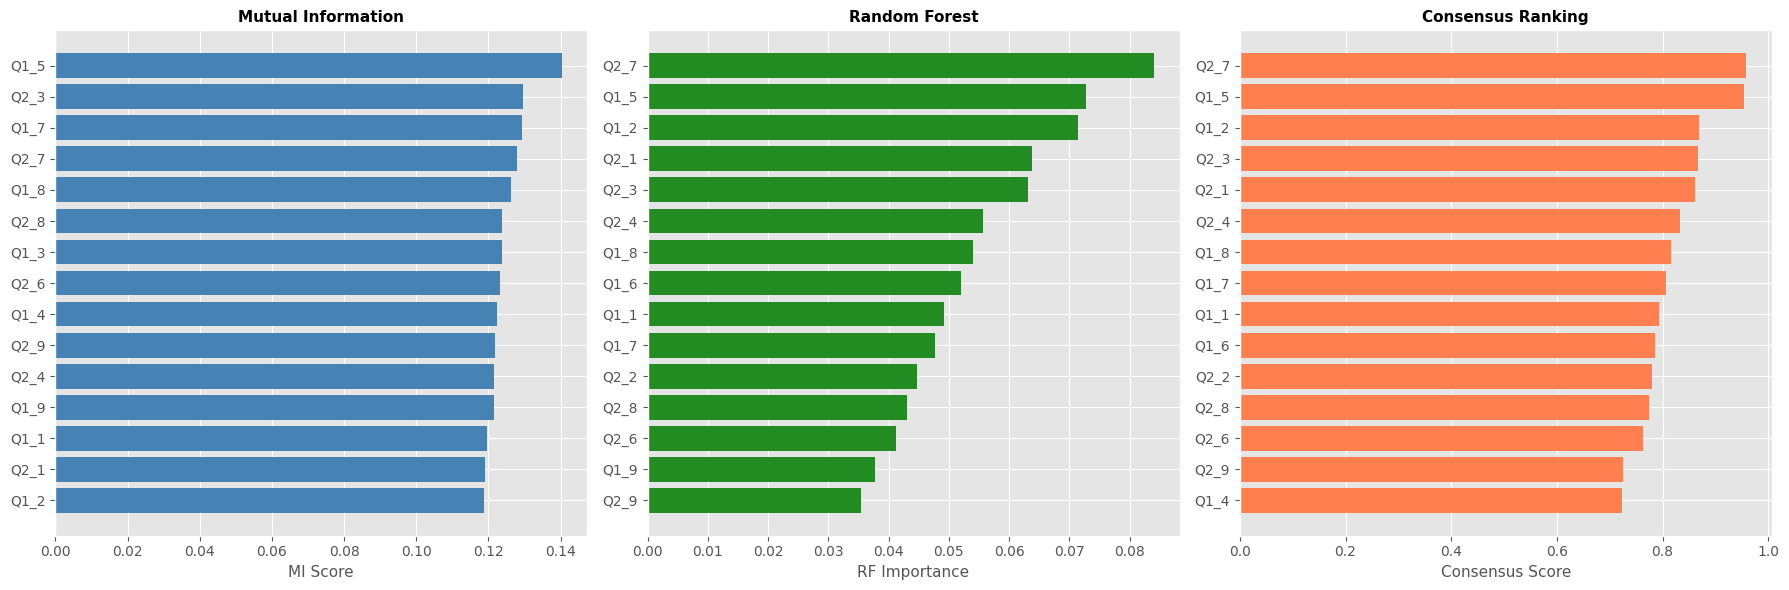

✓ Visualization saved: C:\Users\halid\Desktop\DEHB deneme\Noise_STD_Fazla\New_adhd_data_feature_importance.png

 Ready for model training!


In [3]:
# ====================================================================================
# DATA PREPARATION AND GLOBAL SPLIT  +++++++++++++++++++++++++++++++++++++++++++++++++
# ====================================================================================
print("=" * 80)
print("DATA PREPARATION: EVIDENCE-BASED FEATURE SELECTION")
print("=" * 80)

# ====================================================================================
# STEP 1: LOAD DATASET
# ====================================================================================
df = pd.read_csv(INPUT_FILE_PATH)
print(f"✓ Dataset loaded: {df.shape[0]} samples, {df.shape[1]} features\n")

# ====================================================================================
# STEP 2: TARGET VARIABLE DEFINITION
# ====================================================================================
if 'Diagnosis_Class' in df.columns:
    print(" Original Diagnosis_Class Distribution:")
    print(df['Diagnosis_Class'].value_counts().sort_index())
    
    target_col = 'ADHD_TARGET'
    df['ADHD_TARGET'] = df['Diagnosis_Class'].apply(lambda x: 0 if x == 0 else 1)
    df.drop(columns=['Diagnosis_Class'], inplace=True)
    
    print(f"\n✓ Binary target created: ADHD_TARGET")
    print(f"  Class 0 (No ADHD): {(df['ADHD_TARGET']==0).sum()}")
    print(f"  Class 1 (ADHD):    {(df['ADHD_TARGET']==1).sum()}")
    print(f"  Imbalance ratio:   {(df['ADHD_TARGET']==1).sum() / (df['ADHD_TARGET']==0).sum():.2f}\n")

# ====================================================================================
# STEP 3: REMOVE REDUNDANT FEATURES
# ====================================================================================
# Drop Difficulty_Organizing_Tasks (overlaps with Q1_5, correlation=0.55)
if 'Difficulty_Organizing_Tasks' in df.columns:
    print("  Dropping 'Difficulty_Organizing_Tasks' (redundant with Q1_5)")
    df.drop(columns=['Difficulty_Organizing_Tasks'], inplace=True)
    print("✓ Redundant feature removed\n")

# ====================================================================================
# STEP 4: ORDINAL ENCODING
# ====================================================================================
ordinal_mapping = {'Not Working': 0,'Kindergarten': 1, 'Primary': 2, 'Middle': 3,
    'Secondary': 4, 'University': 5, 'Working': 6}

if 'Educational_Level' in df.columns and df['Educational_Level'].dtype == 'object':
    df['Educational_Level'] = df['Educational_Level'].map(ordinal_mapping)
    print("✓ Educational_Level encoded ordinally")
    
    # NaN check (are there any categories not included in the mapping?)
    missing_after_mapping = df['Educational_Level'].isna().sum()
    if missing_after_mapping > 0:
        print(f"  ⚠️ WARNING: {missing_after_mapping} values could not be mapped!")
    else:
        print("  All categories successfully mapped (0 missing values)\n")



# ====================================================================================
# STEP 5: BINARY COLUMNS CORRECTION (1-2 → 0-1)
# ====================================================================================
for col in BINARY_COLS:
    if col in df.columns and set(df[col].unique()).issubset({1, 2}):
        df[col] = df[col] - 1
        print(f"✓ {col} corrected: [1,2] → [0,1]\n")

# ====================================================================================
# STEP 6: CATEGORICAL ENCODING
# ====================================================================================
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

if categorical_cols:
    print(f" One-hot encoding: {categorical_cols}")
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print(f"✓ Encoding completed\n")

# ====================================================================================
# STEP 7: MISSING VALUE HANDLING
# ====================================================================================
print(" DATA QUALITY:")
missing_count = df.isnull().sum().sum()
print(f"  Missing values: {missing_count}")
print(f"  Duplicates:     {df.duplicated().sum()}")

if missing_count > 0:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)
    
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    
    print("✓ Missing values imputed with median\n")

print(f"  Final shape: {df.shape}\n")

# ====================================================================================
# STEP 8: TRAIN-TEST SPLIT
# ====================================================================================
X_full = df.drop(columns=[target_col])
y = df[target_col]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

print(" TRAIN-TEST SPLIT:")
print(f"  Train: {X_train_full.shape[0]} samples ({X_train_full.shape[0]/len(df)*100:.1f}%)")
print(f"  Test:  {X_test_full.shape[0]} samples ({X_test_full.shape[0]/len(df)*100:.1f}%)")
print(f"  Features: {X_train_full.shape[1]}")
print(f"  Train class: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"  Test class:  {dict(zip(*np.unique(y_test, return_counts=True)))}\n")

# ====================================================================================
# STEP 9: FEATURE SCALING
# ====================================================================================
scaler = StandardScaler()
X_train_scaled_full = scaler.fit_transform(X_train_full)
X_test_scaled_full = scaler.transform(X_test_full)

print("✓ Feature scaling completed (StandardScaler)\n")

# ====================================================================================
# STEP 10: FEATURE SELECTION - 3 METHODS
# ====================================================================================
print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Method 1: Mutual Information
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X_train_scaled_full, y_train, random_state=42)
mi_importance = pd.DataFrame({
    'Feature': X_full.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\n TOP 15 FEATURES (Mutual Information):")
print(mi_importance.head(15).to_string(index=False))

# Method 2: Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_selector = RandomForestClassifier(
    n_estimators=100, random_state=42, max_depth=10, class_weight='balanced'
)
rf_selector.fit(X_train_scaled_full, y_train)

rf_importance = pd.DataFrame({
    'Feature': X_full.columns,
    'RF_Importance': rf_selector.feature_importances_
}).sort_values('RF_Importance', ascending=False)

print("\n TOP 15 FEATURES (Random Forest):")
print(rf_importance.head(15).to_string(index=False))

# Method 3: F-statistic
from sklearn.feature_selection import SelectKBest, f_classif
selector_kbest = SelectKBest(f_classif, k='all')
selector_kbest.fit(X_train_scaled_full, y_train)

f_importance = pd.DataFrame({
    'Feature': X_full.columns,
    'F_Score': selector_kbest.scores_
}).sort_values('F_Score', ascending=False)

print("\n TOP 15 FEATURES (F-statistic):")
print(f_importance.head(15).to_string(index=False))

# ====================================================================================
# STEP 11: CONSENSUS RANKING
# ====================================================================================
# Normalize scores
mi_importance['MI_Normalized'] = (mi_importance['MI_Score'] - mi_importance['MI_Score'].min()) / \
                                  (mi_importance['MI_Score'].max() - mi_importance['MI_Score'].min())
rf_importance['RF_Normalized'] = (rf_importance['RF_Importance'] - rf_importance['RF_Importance'].min()) / \
                                  (rf_importance['RF_Importance'].max() - rf_importance['RF_Importance'].min())
f_importance['F_Normalized'] = (f_importance['F_Score'] - f_importance['F_Score'].min()) / \
                                (f_importance['F_Score'].max() - f_importance['F_Score'].min())

# Merge and average
consensus = mi_importance[['Feature', 'MI_Normalized']].merge(
    rf_importance[['Feature', 'RF_Normalized']], on='Feature'
).merge(
    f_importance[['Feature', 'F_Normalized']], on='Feature'
)

consensus['Consensus_Score'] = (consensus['MI_Normalized'] + 
                                consensus['RF_Normalized'] + 
                                consensus['F_Normalized']) / 3
consensus = consensus.sort_values('Consensus_Score', ascending=False)

print("\n" + "=" * 80)
print(" CONSENSUS FEATURE RANKING")
print("=" * 80)
print(consensus.head(20).to_string(index=False))

# Save ranking
consensus.to_csv(OUTPUT_FILE_PATH.replace('.csv', '_feature_ranking.csv'), index=False)
print(f"\n✓ Full ranking saved: {OUTPUT_FILE_PATH.replace('.csv', '_feature_ranking.csv')}")

# ====================================================================================
# STEP 12: SELECT TOP 15 FEATURES
# ====================================================================================
print("\n" + "=" * 80)
print("SELECTED FEATURES (TOP 15)")
print("=" * 80)

SELECTED_FEATURES = consensus.head(15)['Feature'].tolist()

print(f"\nSelected features:")
for i, feat in enumerate(SELECTED_FEATURES, 1):
    score = consensus[consensus['Feature']==feat]['Consensus_Score'].values[0]
    print(f"  {i:2d}. {feat:40s} (Score: {score:.4f})")

# ====================================================================================
# STEP 13: FINAL DATA PREPARATION
# ====================================================================================
X_train_selected = X_train_full[SELECTED_FEATURES]
X_test_selected = X_test_full[SELECTED_FEATURES]

scaler_final = StandardScaler()
X_train = scaler_final.fit_transform(X_train_selected)
X_test = scaler_final.transform(X_test_selected)

# Deep Learning reshape
X_train_dl = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_dl = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ====================================================================================
# FINAL SUMMARY
# ====================================================================================
print("\n" + "=" * 80)
print(" DATA PREPARATION COMPLETED")
print("=" * 80)
print(f"  Original features:  {X_full.shape[1]}")
print(f"  Selected features:  {len(SELECTED_FEATURES)}")
print(f"  Reduction:          {(1 - len(SELECTED_FEATURES)/X_full.shape[1])*100:.1f}%")
print(f"  Training samples:   {X_train.shape[0]}")
print(f"  Test samples:       {X_test.shape[0]}")
print(f"  DL shape (train):   {X_train_dl.shape}")
print(f"  DL shape (test):    {X_test_dl.shape}")
print("=" * 80 + "\n")

# ====================================================================================
# VISUALIZATION
# ====================================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Mutual Information
top_mi = mi_importance.head(15)
axes[0].barh(range(len(top_mi)), top_mi['MI_Score'], color='steelblue')
axes[0].set_yticks(range(len(top_mi)))
axes[0].set_yticklabels(top_mi['Feature'], fontsize=10)
axes[0].set_xlabel('MI Score', fontsize=11)
axes[0].set_title('Mutual Information', fontsize=11, fontweight='bold')
axes[0].invert_yaxis()

# Plot 2: Random Forest
top_rf = rf_importance.head(15)
axes[1].barh(range(len(top_rf)), top_rf['RF_Importance'], color='forestgreen')
axes[1].set_yticks(range(len(top_rf)))
axes[1].set_yticklabels(top_rf['Feature'], fontsize=10)
axes[1].set_xlabel('RF Importance', fontsize=11)
axes[1].set_title('Random Forest', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()

# Plot 3: Consensus
top_consensus = consensus.head(15)
axes[2].barh(range(len(top_consensus)), top_consensus['Consensus_Score'], color='coral')
axes[2].set_yticks(range(len(top_consensus)))
axes[2].set_yticklabels(top_consensus['Feature'], fontsize=10)
axes[2].set_xlabel('Consensus Score', fontsize=11)
axes[2].set_title('Consensus Ranking', fontsize=11, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_FILE_PATH.replace('.csv', '_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Visualization saved: {OUTPUT_FILE_PATH.replace('.csv', '_feature_importance.png')}\n")
print(" Ready for model training!")


VISUALIZING TOP 15 SELECTED FEATURES (FEATURE SELECTION RESULTS)
✓ Loaded 15 features from consensus ranking
  Top feature: Q2_7 (Score: 0.9588)


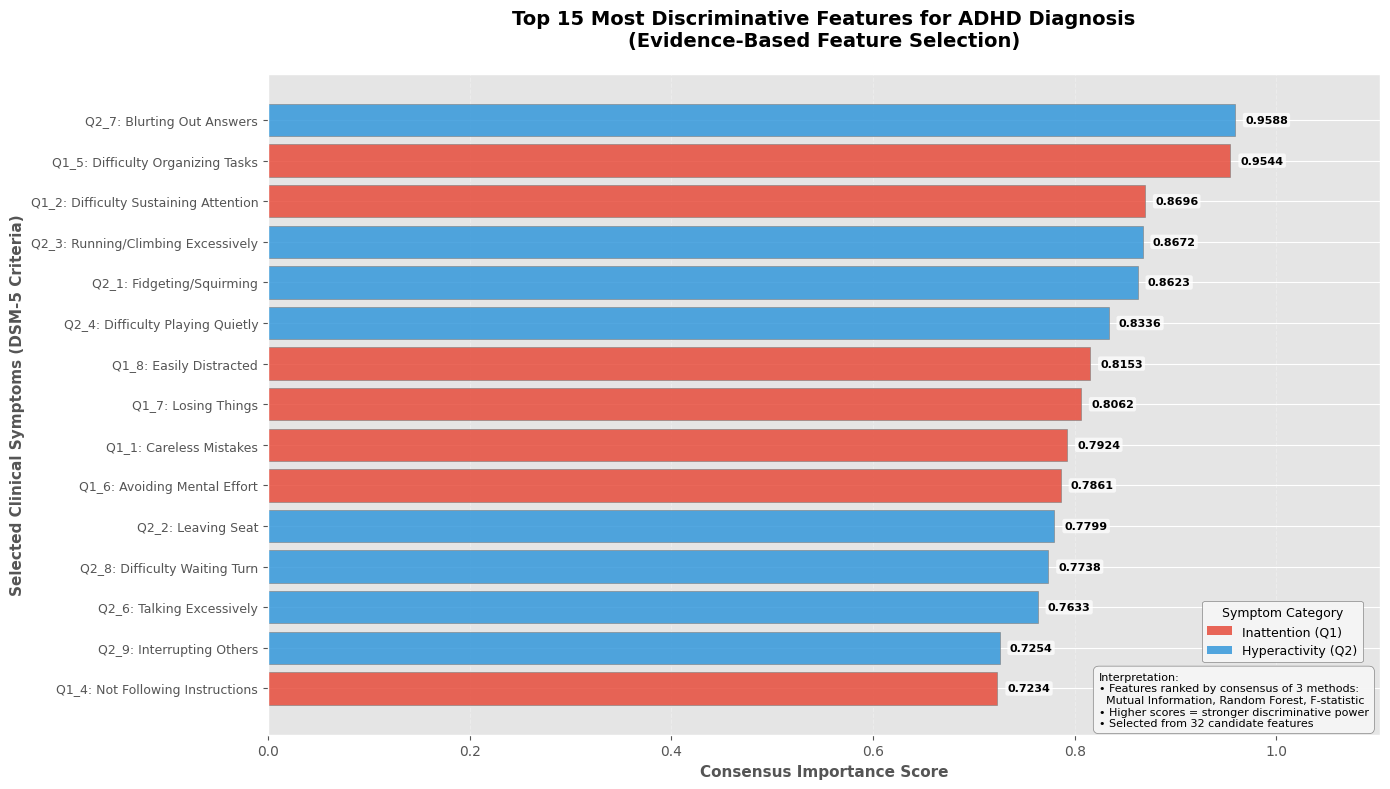


✓ Visualization saved: Top_15_Selected_Features.png

 TOP 15 FEATURE RANKING TABLE

 Rank Feature Code      DSM-5 Clinical Description  Importance Score           Category
    1         Q2_7            Blurting Out Answers          0.958828 Hyperactivity (Q2)
    2         Q1_5     Difficulty Organizing Tasks          0.954416   Inattention (Q1)
    3         Q1_2 Difficulty Sustaining Attention          0.869626   Inattention (Q1)
    4         Q2_3    Running/Climbing Excessively          0.867174 Hyperactivity (Q2)
    5         Q2_1             Fidgeting/Squirming          0.862326 Hyperactivity (Q2)
    6         Q2_4      Difficulty Playing Quietly          0.833557 Hyperactivity (Q2)
    7         Q1_8               Easily Distracted          0.815280   Inattention (Q1)
    8         Q1_7                   Losing Things          0.806161   Inattention (Q1)
    9         Q1_1               Careless Mistakes          0.792440   Inattention (Q1)
   10         Q1_6          Avoidin

In [4]:
# ====================================================================================
# CELL 4: TOP 15 SELECTED FEATURES VISUALIZATION & REPORT TABLE ++++++++++++++++++++++
# ====================================================================================

print("\n" + "=" * 80)
print("VISUALIZING TOP 15 SELECTED FEATURES (FEATURE SELECTION RESULTS)")
print("=" * 80)

# ====================================================================================
# 1. DYNAMICALLY GET SELECTED FEATURES FROM CELL 3
# ====================================================================================
if 'consensus' not in globals() or 'SELECTED_FEATURES' not in globals():
    print(" ERROR: 'consensus' DataFrame or 'SELECTED_FEATURES' not found!")
    print("   Please run Cell 3 (Data Preparation) first.")
else:
    # Extract top 15 features with their consensus scores
    feat_df = consensus.head(15)[['Feature', 'Consensus_Score']].copy()
    feat_df.columns = ['Feature', 'Score']
    
    print(f"✓ Loaded {len(feat_df)} features from consensus ranking")
    print(f"  Top feature: {feat_df.iloc[0]['Feature']} (Score: {feat_df.iloc[0]['Score']:.4f})")
    
    # ====================================================================================
    # 2. DSM-5 SYMPTOM LABELS
    # ====================================================================================
    dsm5_labels = {
        # INATTENTION SYMPTOMS (Q1)
        'Q1_1': 'Careless Mistakes',
        'Q1_2': 'Difficulty Sustaining Attention',
        'Q1_3': 'Not Listening',
        'Q1_4': 'Not Following Instructions',
        'Q1_5': 'Difficulty Organizing Tasks',
        'Q1_6': 'Avoiding Mental Effort',
        'Q1_7': 'Losing Things',
        'Q1_8': 'Easily Distracted',
        'Q1_9': 'Forgetful in Daily Activities',
        
        # HYPERACTIVITY/IMPULSIVITY SYMPTOMS (Q2)
        'Q2_1': 'Fidgeting/Squirming',
        'Q2_2': 'Leaving Seat',
        'Q2_3': 'Running/Climbing Excessively',
        'Q2_4': 'Difficulty Playing Quietly',
        'Q2_5': 'Always "On the Go"',
        'Q2_6': 'Talking Excessively',
        'Q2_7': 'Blurting Out Answers',
        'Q2_8': 'Difficulty Waiting Turn',
        'Q2_9': 'Interrupting Others',
        
        # OTHER FEATURES (if selected)
        'Difficulty_Organizing_Tasks': 'Task Organization Difficulty',
        'Focus_Score_Video': 'Video Focus Score',
        'Learning_Difficulties': 'Learning Difficulties',
        'Anxiety_Depression_Levels': 'Anxiety/Depression Level',
        'Sleep_Hours': 'Sleep Duration',
        'Daily_Activity_Hours': 'Physical Activity',
        'Daily_Phone_Usage_Hours': 'Screen Time',
        'Age': 'Age',
        'Gender': 'Gender',
        'Educational_Level': 'Educational Level',
        'Family_History_Yes': 'Family History of ADHD'
    }
    
    # ====================================================================================
    # 3. DATA PROCESSING FOR VISUALIZATION
    # ====================================================================================
    # Add descriptions
    feat_df['Description'] = feat_df['Feature'].map(dsm5_labels)
    
    # Handle features without DSM-5 labels
    feat_df['Description'] = feat_df['Description'].fillna(feat_df['Feature'])
    
    # Create combined label
    feat_df['Label'] = feat_df['Feature'] + ": " + feat_df['Description']
    
    # Categorize features
    def categorize_feature(feat):
        if feat.startswith('Q1_'):
            return 'Inattention (Q1)'
        elif feat.startswith('Q2_'):
            return 'Hyperactivity (Q2)'
        else:
            return 'Other Clinical'
    
    feat_df['Category_Code'] = feat_df['Feature'].apply(categorize_feature)
    
    # Sort for plotting (ascending for horizontal bar - highest at top when plotted)
    feat_df = feat_df.sort_values('Score', ascending=True)
    
    # ====================================================================================
    # 4. VISUALIZATION - HORIZONTAL BAR CHART
    # ====================================================================================

    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Color mapping
    color_map = {
        'Inattention (Q1)': '#e74c3c',       # Red
        'Hyperactivity (Q2)': '#3498db',     # Blue
        'Other Clinical': '#2ecc71'          # Green
    }
    colors = feat_df['Category_Code'].map(color_map)
    
    # Create bars
    bars = ax.barh(feat_df['Label'], feat_df['Score'], color=colors, alpha=0.85, edgecolor='gray', linewidth=0.5)
    
    # Title and labels
    ax.set_title('Top 15 Most Discriminative Features for ADHD Diagnosis\n(Evidence-Based Feature Selection)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Consensus Importance Score', fontsize=11, fontweight='bold')
    ax.set_ylabel('Selected Clinical Symptoms (DSM-5 Criteria)', fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.set_xlim(0, max(feat_df['Score']) * 1.15)
    
    # Annotate bars with scores
    for i, (idx, row) in enumerate(feat_df.iterrows()):
        ax.text(row['Score'] + 0.01, i, f"{row['Score']:.4f}", 
                va='center', fontsize=8, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))
    
    # Legend
    from matplotlib.patches import Patch
    unique_categories = feat_df['Category_Code'].unique()
    legend_elements = [Patch(facecolor=color_map[cat], label=cat, alpha=0.85) 
                      for cat in unique_categories if cat in color_map]
    
    ax.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.99, 0.10),
           fontsize=9, framealpha=0.95, facecolor='#f5f5f5', edgecolor='gray',
           title='Symptom Category', title_fontsize=9)
 
    # Interpretation box
    interpretation_text = (
        "Interpretation:\n"
        "• Features ranked by consensus of 3 methods:\n"
        "  Mutual Information, Random Forest, F-statistic\n"
        "• Higher scores = stronger discriminative power\n"
        "• Selected from 32 candidate features"
    )
    ax.text(0.99, 0.01, interpretation_text, transform=ax.transAxes, fontsize=8,
        verticalalignment='bottom', horizontalalignment='right', multialignment='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5', edgecolor='gray', alpha=0.95))

    plt.tight_layout()
    plt.savefig('Top_15_Selected_Features.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualization saved: Top_15_Selected_Features.png")
    
    # ====================================================================================
    # 5. REPORT TABLE GENERATION
    # ====================================================================================
    print("\n" + "=" * 80)
    print(" TOP 15 FEATURE RANKING TABLE")
    print("=" * 80)
    
    # Prepare table (highest score first)
    table_df = feat_df.sort_values('Score', ascending=False).copy()
    
    # Add rank
    table_df['Rank'] = range(1, len(table_df) + 1)
    
    # Format category for table
    table_df['Category_Formatted'] = table_df['Category_Code']
    
    # Select columns for final table
    final_table = table_df[['Rank', 'Feature', 'Description', 'Score', 'Category_Formatted']].copy()
    final_table.columns = [
        'Rank', 
        'Feature Code', 
        'DSM-5 Clinical Description', 
        'Importance Score', 
        'Category'
    ]
    
    # Display table
    print("\n" + final_table.to_string(index=False))
    
    # ====================================================================================
    # 6. SUMMARY STATISTICS
    # ====================================================================================
    print("\n" + "=" * 80)
    print(" FEATURE SELECTION SUMMARY")
    print("=" * 80)
    
    # Count by category
    category_counts = feat_df['Category_Code'].value_counts()
    print("\n🔹 Distribution by Category:")
    for cat, count in category_counts.items():
        pct = (count / len(feat_df)) * 100
        print(f"   {cat:25s}: {count:2d} features ({pct:5.1f}%)")
    
    # Score statistics
    print(f"\n Score Statistics:")
    print(f"   Highest score: {feat_df['Score'].max():.4f} ({feat_df[feat_df['Score'] == feat_df['Score'].max()]['Feature'].values[0]})")
    print(f"   Lowest score:  {feat_df['Score'].min():.4f} ({feat_df[feat_df['Score'] == feat_df['Score'].min()]['Feature'].values[0]})")
    print(f"   Mean score:    {feat_df['Score'].mean():.4f}")
    print(f"   Median score:  {feat_df['Score'].median():.4f}")
    
    # Feature reduction info
    original_features = len(consensus)
    selected_features = len(feat_df)
    reduction_pct = (1 - selected_features/original_features) * 100
    
    print(f"\n🔹 Dimensionality Reduction:")
    print(f"   Original features:  {original_features}")
    print(f"   Selected features:  {selected_features}")
    print(f"   Reduction:          {reduction_pct:.1f}%")
    
    print("\n" + "=" * 80)
    print(" Feature visualization and reporting completed!")
    print("=" * 80)


LOGISTIC REGRESSION (LR) - HYPERPARAMETER TUNING FOR ADHD DIAGNOSIS
 Dataset Statistics:
    Train samples: 4550
    Test samples:  1950
    Feature count: 15
    Target Balance (Train): [1102 3448] (0: No ADHD, 1: ADHD)

⏳ Starting 5-Fold Grid Search (Logistic Regression)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✓ Grid Search completed in 3.9983 sec
✓ Best PR-AUC (CV): 0.9884
✓ Best Hyperparameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}

 Optimizing decision threshold using CV predictions (MCC)...
✓ Optimal Threshold (CV-based): 0.632
✓ Max MCC (CV): 0.8866

TRAINING FINAL LOGISTIC REGRESSION MODEL

 Training final LR model on full training set...
✓ Final model training completed in 5.792 ms

 Measuring realistic inference latency...

 Evaluating on test set...

LOGISTIC REGRESSION - FINAL RESULTS

✓ Accuracy (Threshold 0.63): 0.9456
✓ F1-Score: 0.9641
✓ ROC-AUC Score: 0.9524
✓ PR-AUC Score:  0.9719
✓ MCC Score:     0.8525
✓ Cohen'

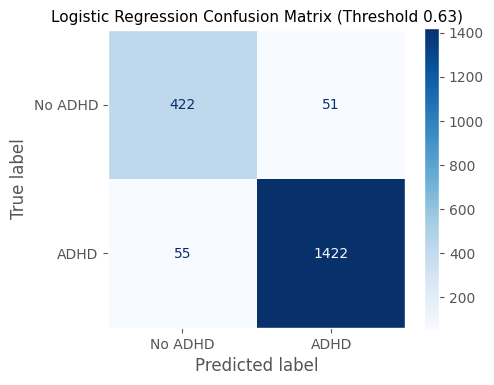


 Timing and metrics stored successfully.
    Grid Search:    3.9983 sec
    Training:       5.792 ms
    Inference:      290.328 ms
    Latency:        0.148886 ms/sample
    Total Time:     4.2944 sec


In [5]:
# ====================================================================================
# LOGISTIC REGRESSION (LR) - ACADEMIC PIPELINE WITH 5-FOLD CV (ADHD DIAGNOSIS)   +++++
# ====================================================================================

print("\n" + "=" * 80)
print("LOGISTIC REGRESSION (LR) - HYPERPARAMETER TUNING FOR ADHD DIAGNOSIS")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (FROM GLOBAL DATA PREP CELL)
# ================================================================================
print(f" Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Feature count: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: No ADHD, 1: ADHD)")

# ================================================================================
# HYPERPARAMETER TUNING (5-FOLD CV WITH PR-AUC)
# ================================================================================
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["liblinear", "lbfgs"],
    "max_iter": [1000]
}

lr_base = LogisticRegression(random_state=42)

lr_clf = GridSearchCV(
    lr_base,
    param_grid=lr_param_grid,
    scoring="average_precision",   # PR-AUC for imbalanced medical data
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    refit=False  # Important: We train manually below to measure time accurately
)

print("\n⏳ Starting 5-Fold Grid Search (Logistic Regression)...")
timer.start("lr_grid")
lr_clf.fit(X_train, y_train)
lr_grid_time = timer.stop("lr_grid")

print(f"\n✓ Grid Search completed in {format_time(lr_grid_time)}")
print(f"✓ Best PR-AUC (CV): {lr_clf.best_score_:.4f}")
print(f"✓ Best Hyperparameters: {lr_clf.best_params_}")

# ================================================================================
# THRESHOLD OPTIMIZATION (CV-BASED MCC)
# ================================================================================
print("\n Optimizing decision threshold using CV predictions (MCC)...")

# Temporary model for threshold optimization using best params
temp_lr = LogisticRegression(
    **lr_clf.best_params_,
    random_state=42
)
temp_lr.fit(X_train, y_train)

# Global utility function usage
optimal_threshold, max_mcc_cv = optimize_threshold_cv(
    temp_lr,
    X_train,
    y_train,
    cv=5
)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")

# ================================================================================
# FINAL MODEL TRAINING
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL LOGISTIC REGRESSION MODEL")
print("=" * 80)

best_lr = LogisticRegression(
    **lr_clf.best_params_,
    random_state=42
)

print("\n Training final LR model on full training set...")
timer.start("lr_train")
best_lr.fit(X_train, y_train)
lr_training_time = timer.stop("lr_train")

print(f"✓ Final model training completed in {format_time(lr_training_time)}")

# ================================================================================
# INFERENCE LATENCY MEASUREMENT
# ================================================================================
print("\n Measuring realistic inference latency...")

inference_time_total, latency_ms = measure_inference_latency(
    best_lr,
    X_test
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n Evaluating on test set...")

lr_pred_proba = best_lr.predict_proba(X_test)[:, 1]
best_lr_predict = (lr_pred_proba >= optimal_threshold).astype(int)

# Global utility function usage
metrics = compute_metrics(
    y_test,
    best_lr_predict,
    lr_pred_proba
)

model_size_mb = get_model_size_mb(best_lr)

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("LOGISTIC REGRESSION - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:    {model_size_mb:.4f} MB")

print("\n Classification Report:")
print(classification_report(
    y_test,
    best_lr_predict,
    target_names=["No ADHD", "ADHD"]
))

# ================================================================================
# CONFUSION MATRIX 
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="Logistic Regression",
    threshold=optimal_threshold,
    cmap='Blues'  # Standard color for Classical Models
)

# ================================================================================
# RESULTS ARCHIVING
# ================================================================================
total_time = lr_grid_time + lr_training_time + inference_time_total
fpr_score = 1 - metrics["Specificity"]

model_results["LR"] = {
    "Accuracy": metrics["Accuracy"],
    "Precision": metrics["Precision"],
    "Recall": metrics["Recall"],
    "F1_Score": metrics["F1_Score"],
    "MCC": metrics["MCC"],
    "Kappa": metrics["Kappa"],
    "ROC_AUC": metrics["ROC_AUC"],
    "PR_AUC": metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR": fpr_score,
    "Model_Size_MB": model_size_mb,
    "Category": "Classical"
}

model_time_results["LR"] = {
    "CV_Time": lr_grid_time,
    "Training_Time": lr_training_time,
    "Inference_Time_Sec": inference_time_total,
    "Latency_ms": latency_ms,
    "Total_Time": total_time
}

print("\n Timing and metrics stored successfully.")
print(f"    Grid Search:    {format_time(lr_grid_time)}")
print(f"    Training:       {format_time(lr_training_time)}")
print(f"    Inference:      {format_time(inference_time_total)}")
print(f"    Latency:        {latency_ms:.6f} ms/sample")
print(f"    Total Time:     {format_time(total_time)}")
print("=" * 80)

## Ensemble Models

### CatBoost (Categorical Boosting)


CATBOOST - HYPERPARAMETER TUNING FOR ADHD DIAGNOSIS
 Dataset Statistics:
    Train samples: 4550
    Test samples:  1950
    Feature count: 15
    Target Balance (Train): [1102 3448] (0: No ADHD, 1: ADHD)

 Starting 5-Fold Grid Search (CatBoost is robust against overfitting)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

✓ Grid Search completed in 41.8993 sec
✓ Best PR-AUC (CV): 0.9918
✓ Best Parameters: {'depth': 8, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.05}

 Optimizing decision threshold using CV-based MCC...
✓ Optimal Threshold (CV-based): 0.614
✓ Max MCC (CV): 0.8976

TRAINING FINAL CATBOOST MODEL

 Training final CatBoost model on full training set...
✓ Final model training completed in 689.216 ms

 Measuring realistic inference latency...

 Evaluating on test set...

CATBOOST - FINAL RESULTS

✓ Accuracy (Threshold 0.61): 0.9508
✓ F1-Score: 0.9675
✓ ROC-AUC Score: 0.9590
✓ PR-AUC Score:  0.9823
✓ MCC Score:     0.8658
✓ Cohen's Kappa: 0.8658
✓

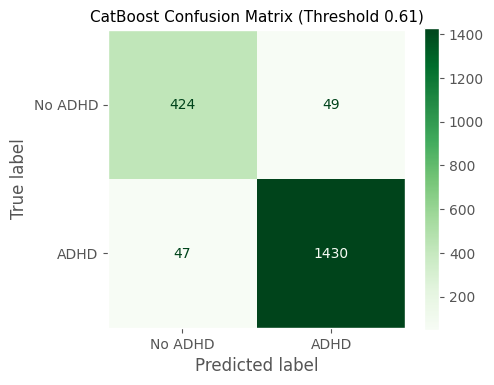


 Timing and metrics stored successfully.
    Grid Search:    41.8993 sec
    Training:       689.216 ms
    Inference:      1.1517 sec
    Latency:        0.590639 ms/sample
    Total Time:     43.7403 sec


In [12]:
# ====================================================================================
# CATBOOST MODEL - ACADEMIC PIPELINE WITH 5-FOLD CV (ADHD DIAGNOSIS)  ++++++++++++++++
# ====================================================================================

print("\n" + "=" * 80)
print("CATBOOST - HYPERPARAMETER TUNING FOR ADHD DIAGNOSIS")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (FROM GLOBAL DATA PREP CELL)
# ================================================================================
print(f" Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Feature count: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: No ADHD, 1: ADHD)")

# ================================================================================
# HYPERPARAMETER TUNING (5-FOLD CV WITH PR-AUC)
# ================================================================================
# CatBoost is robust, but tuning depth and learning_rate is beneficial
cat_param_grid = {
    'iterations': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

cat_base = CatBoostClassifier(random_state=42, allow_writing_files=False)

cat_clf = GridSearchCV(
    cat_base,
    param_grid=cat_param_grid,
    scoring='average_precision', # PR-AUC for imbalanced data
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    refit=False  # Important: We train manually below to measure time accurately
)

print("\n Starting 5-Fold Grid Search (CatBoost is robust against overfitting)...")
timer.start("cat_grid")
cat_clf.fit(X_train, y_train)
cat_grid_time = timer.stop("cat_grid")

print(f"\n✓ Grid Search completed in {format_time(cat_grid_time)}")
print(f"✓ Best PR-AUC (CV): {cat_clf.best_score_:.4f}")
print(f"✓ Best Parameters: {cat_clf.best_params_}")

# ================================================================================
# THRESHOLD OPTIMIZATION (CV-BASED MCC)
# ================================================================================
print("\n Optimizing decision threshold using CV-based MCC...")

# Creating a fresh estimator using best params because refit=False
temp_cat = CatBoostClassifier(
    **cat_clf.best_params_, 
    random_state=42, 
    allow_writing_files=False,
    verbose=0 
)
temp_cat.fit(X_train, y_train)

# Global utility function usage
optimal_threshold, max_mcc_cv = optimize_threshold_cv(
    temp_cat,
    X_train,
    y_train,
    cv=5
)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (FULL TRAIN SET WITH TRUE TIMING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL CATBOOST MODEL")
print("=" * 80)

# Instantiate NEW model with best parameters
best_cat = CatBoostClassifier(
    **cat_clf.best_params_,
    random_state=42,
    allow_writing_files=False,
    verbose=0
)

print("\n Training final CatBoost model on full training set...")
timer.start("cat_train")
best_cat.fit(X_train, y_train)
cat_training_time = timer.stop("cat_train") # Now measuring actual training time

print(f"✓ Final model training completed in {format_time(cat_training_time)}")

# ================================================================================
# INFERENCE LATENCY MEASUREMENT
# ================================================================================
print("\n Measuring realistic inference latency...")

# Global utility function usage
inference_time_total, latency_ms = measure_inference_latency(
    best_cat,
    X_test
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n Evaluating on test set...")

cat_pred_proba = best_cat.predict_proba(X_test)[:, 1]
best_cat_predict = (cat_pred_proba >= optimal_threshold).astype(int)

# Global utility function usage
metrics = compute_metrics(
    y_test,
    best_cat_predict,
    cat_pred_proba
)

model_size_mb = get_model_size_mb(best_cat)

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("CATBOOST - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:    {model_size_mb:.4f} MB")

print("\n Classification Report:")
print(classification_report(
    y_test,
    best_cat_predict,
    target_names=["No ADHD", "ADHD"]
))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="CatBoost",
    threshold=optimal_threshold,
    cmap="Greens" # Green color map for Ensemble Models
)

# ================================================================================
# RESULTS ARCHIVING
# ================================================================================
total_time = cat_grid_time + cat_training_time + inference_time_total
fpr_score = 1 - metrics["Specificity"]

model_results["CatBoost"] = {
    "Accuracy": metrics["Accuracy"],
    "Precision": metrics["Precision"],
    "Recall": metrics["Recall"],
    "F1_Score": metrics["F1_Score"],
    "MCC": metrics["MCC"],
    "Kappa": metrics["Kappa"],
    "ROC_AUC": metrics["ROC_AUC"],
    "PR_AUC": metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR": fpr_score,
    "Model_Size_MB": model_size_mb,
    "Category": "Ensemble"
}

model_time_results["CatBoost"] = {
    "CV_Time": cat_grid_time,
    "Training_Time": cat_training_time,
    "Inference_Time_Sec": inference_time_total,
    "Latency_ms": latency_ms,
    "Total_Time": total_time
}

print("\n Timing and metrics stored successfully.")
print(f"    Grid Search:    {format_time(cat_grid_time)}")
print(f"    Training:       {format_time(cat_training_time)}")
print(f"    Inference:      {format_time(inference_time_total)}")
print(f"    Latency:        {latency_ms:.6f} ms/sample")
print(f"    Total Time:     {format_time(total_time)}")
print("=" * 80)

## Deep Learning Models

### LSTM (LONG SHORT-TERM MEMORY)


LSTM (LONG SHORT-TERM MEMORY) - TRAINING & OPTIMIZATION FOR ADHD DIAGNOSIS
 Data Shapes for LSTM:
    Train samples: 4550
    Test samples:  1950
    Input Shape:   (15, 1)
    Target Balance (Train): [1102 3448] (0: No ADHD, 1: ADHD)

 Starting 5-Fold Cross-Validation (Manual Loop)...
Fold   PR-AUC    
--------------------
1      0.9922
2      0.9881
3      0.9901
4      0.9838
5      0.9902
--------------------
✓ CV completed in 115.3458 sec
✓ Average PR-AUC (CV): 0.9889 (±0.0028)

 Optimizing decision threshold using aggregated CV predictions...
✓ Optimal Threshold (CV-based): 0.624
✓ Max MCC (CV): 0.8902

TRAINING FINAL LSTM MODEL

 Training final LSTM model on full training set...
Epoch 1/25
114/114 [==============================] - 4s 15ms/step - loss: 0.2592 - accuracy: 0.9423 - val_loss: 0.3645 - val_accuracy: 0.9429 - lr: 0.0010
Epoch 2/25
114/114 [==============================] - 1s 12ms/step - loss: 0.2073 - accuracy: 0.9566 - val_loss: 0.2390 - val_accuracy: 0.9451 - lr:

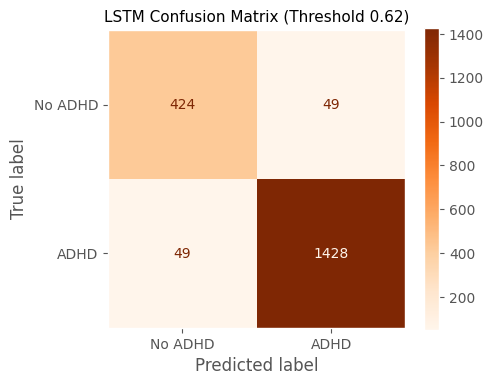


 Timing and metrics stored successfully.
    CV (Robustness): 115.3458 sec
    Final Training:  30.8959 sec
    Inference:       83.7737 sec
    Latency:         42.960880 ms/sample
    Total Time:      230.0154 sec


In [20]:
# ====================================================================================
# LSTM (LONG SHORT-TERM MEMORY) - ACADEMIC PIPELINE WITH 5-FOLD CV (ADHD)  ++++++++++
# ====================================================================================

print("\n" + "=" * 80)
print("LSTM (LONG SHORT-TERM MEMORY) - TRAINING & OPTIMIZATION FOR ADHD DIAGNOSIS")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (Using 3D Data for Deep Learning)
# ================================================================================
print(f" Data Shapes for LSTM:")
print(f"    Train samples: {X_train_dl.shape[0]}")
print(f"    Test samples:  {X_test_dl.shape[0]}")
print(f"    Input Shape:   {X_train_dl.shape[1:]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: No ADHD, 1: ADHD)")

# ================================================================================
# MODEL ARCHITECTURE
# ================================================================================
def build_lstm(input_shape):
    tf.keras.backend.clear_session()
    model = Sequential([
        Input(shape=input_shape),
        
        # 1st LSTM Layer: Captures long-term dependencies
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        
        # 2nd LSTM Layer: Extracts summary features
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        
        # Decision Layers
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001), 
        loss='binary_crossentropy', 
        metrics=['accuracy']
    )
    return model

# ================================================================================
# 5-FOLD CROSS-VALIDATION (MANUAL LOOP)
# ================================================================================
print("\n Starting 5-Fold Cross-Validation (Manual Loop)...")
timer.start("lstm_cv")

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_predictions = []
cv_true_labels = []
cv_pr_scores = []

early_stop_cv = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True, 
    verbose=0
)

print(f"{'Fold':<6} {'PR-AUC':<10}")
print("-" * 20)

for fold_no, (train_idx, val_idx) in enumerate(kfold.split(X_train_dl, y_train), 1):
    # Data Split
    X_train_fold, X_val_fold = X_train_dl[train_idx], X_train_dl[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
    
    # Build & Train
    model_cv = build_lstm(input_shape=(X_train_dl.shape[1], 1))
    
    model_cv.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=20, 
        batch_size=32,
        callbacks=[early_stop_cv],
        verbose=0
    )
    
    # Predict
    val_probs = model_cv.predict(X_val_fold, verbose=0).flatten()
    
    # Score
    score = average_precision_score(y_val_fold, val_probs)
    cv_pr_scores.append(score)
    
    # Store for Threshold Optimization
    cv_predictions.extend(val_probs)
    cv_true_labels.extend(y_val_fold)
    
    print(f"{fold_no:<6} {score:.4f}")

lstm_cv_time = timer.stop("lstm_cv")

print("-" * 20)
print(f"✓ CV completed in {format_time(lstm_cv_time)}")
print(f"✓ Average PR-AUC (CV): {np.mean(cv_pr_scores):.4f} (±{np.std(cv_pr_scores):.4f})")

# ================================================================================
# THRESHOLD OPTIMIZATION (Using Aggregated CV Predictions)
# ================================================================================
print("\n Optimizing decision threshold using aggregated CV predictions...")

thresholds = np.linspace(0.01, 0.99, 100)
cv_preds_arr = np.array(cv_predictions)
cv_true_arr = np.array(cv_true_labels)

mcc_scores = [
    matthews_corrcoef(cv_true_arr, (cv_preds_arr >= t).astype(int)) 
    for t in thresholds
]
optimal_threshold = thresholds[np.argmax(mcc_scores)]
max_mcc_cv = max(mcc_scores)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (FULL TRAIN SET)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL LSTM MODEL")
print("=" * 80)

# Build Final Model
lstm_model = build_lstm(input_shape=(X_train_dl.shape[1], 1))

# Callbacks
early_stop_final = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True, 
    verbose=1
)
reduce_lr_final = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    verbose=1
)

print("\n Training final LSTM model on full training set...")
timer.start("lstm_train")

history = lstm_model.fit(
    X_train_dl, y_train,
    validation_split=0.2, 
    epochs=25,
    batch_size=32,
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=1
)

lstm_training_time = timer.stop("lstm_train")
print(f"✓ Final model training completed in {format_time(lstm_training_time)}")

# ================================================================================
# INFERENCE LATENCY MEASUREMENT
# ================================================================================
print("\n Measuring realistic inference latency...")

# Warm-up
lstm_model.predict(X_test_dl[:5], verbose=0)

start_time = time.perf_counter()
for i in range(X_test_dl.shape[0]):
    sample = X_test_dl[i:i+1]
    lstm_model.predict(sample, verbose=0)
end_time = time.perf_counter()

inference_time_total = end_time - start_time
latency_ms = (inference_time_total / X_test_dl.shape[0]) * 1000

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n Evaluating on test set...")

# Predict Probabilities
lstm_pred_proba = lstm_model.predict(X_test_dl, verbose=0).flatten()

# Apply Optimal Threshold
best_lstm_predict = (lstm_pred_proba >= optimal_threshold).astype(int)

# Calculate Metrics
metrics = compute_metrics(
    y_test,
    best_lstm_predict,
    lstm_pred_proba
)

# Calculate Model Size
model_size_mb = 0
temp_filename = "temp_lstm_model_size.h5"
try:
    lstm_model.save(temp_filename)
    model_size_mb = os.path.getsize(temp_filename) / (1024 * 1024)
    os.remove(temp_filename)
except Exception as e:
    print(f" Could not calculate model size: {e}")

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("LSTM - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:    {model_size_mb:.4f} MB")

print("\n Classification Report:")
print(classification_report(
    y_test, 
    best_lstm_predict, 
    target_names=['No ADHD', 'ADHD']
))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="LSTM",
    threshold=optimal_threshold,
    cmap='Oranges'
)

# ================================================================================
# RESULTS ARCHIVING
# ================================================================================
total_time = lstm_cv_time + lstm_training_time + inference_time_total
fpr_score = 1 - metrics["Specificity"]

model_results["LSTM"] = {
    "Accuracy": metrics["Accuracy"],
    "Precision": metrics["Precision"],
    "Recall": metrics["Recall"],
    "F1_Score": metrics["F1_Score"],
    "MCC": metrics["MCC"],
    "Kappa": metrics["Kappa"],
    "ROC_AUC": metrics["ROC_AUC"],
    "PR_AUC": metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR": fpr_score,
    "Model_Size_MB": model_size_mb,
    "Category": "Deep Learning"
}

model_time_results["LSTM"] = {
    "CV_Time": lstm_cv_time,
    "Training_Time": lstm_training_time,
    "Inference_Time_Sec": inference_time_total,
    "Latency_ms": latency_ms,
    "Total_Time": total_time
}

print("\n Timing and metrics stored successfully.")
print(f"    CV (Robustness): {format_time(lstm_cv_time)}")
print(f"    Final Training:  {format_time(lstm_training_time)}")
print(f"    Inference:       {format_time(inference_time_total)}")
print(f"    Latency:         {latency_ms:.6f} ms/sample")
print(f"    Total Time:      {format_time(total_time)}")
print("=" * 80)

In [48]:
# =============================================================================
# COMPREHENSIVE MODEL COMPARISON (ALL METRICS, NO TIME)
# =============================================================================

print("\n" + "=" * 135)
print("FINAL COMPREHENSIVE MODEL COMPARISON - ADHD DIAGNOSIS PREDICTION")
print("=" * 135)

# 1. CHECK AND AGGREGATE DATA
# -----------------------------------------------------------------------------
if 'model_results' not in globals() or not model_results:
    print(" Error: 'model_results' dictionary not found or empty.")
else:
    # Convert global dictionary to DataFrame directly
    rows = []
    for model_name, metrics in model_results.items():
        row = metrics.copy()
        row['Model'] = model_name
        
        # Ensure Category exists
        if 'Category' not in row:
            row['Category'] = 'Unknown'
            
        rows.append(row)

    final_df = pd.DataFrame(rows)

    # 2. COLUMN MAPPING (To match your specific requested output names)
    # -----------------------------------------------------------------------------
    # Map internal keys to display headers
    # Internal Key -> Display Header
    rename_map = {
        'Accuracy': 'Acc',
        'Precision': 'Prec',
        'Recall': 'Recall',
        'F1_Score': 'F1',
        'MCC': 'MCC',
        'Kappa': 'Kappa',
        'ROC_AUC': 'ROC-AUC',
        'PR_AUC': 'PR-AUC',
        'Specificity': 'Spec',
        'FPR': 'FPR',
        'Model_Size_MB': 'Size(MB)'
    }
    final_df.rename(columns=rename_map, inplace=True)
    
    # Define Column Order
    cols_order = ['Model', 'Category', 'Acc', 'Prec', 'Recall', 'F1', 'MCC', 'Kappa', 
                  'ROC-AUC', 'PR-AUC', 'Spec', 'FPR', 'Size(MB)']
    
    # Filter columns that exist
    cols_order = [c for c in cols_order if c in final_df.columns]
    final_df = final_df[cols_order]

    # 3. SORTING & RANKING
    # -----------------------------------------------------------------------------
    # Sort by ROC-AUC (primary) descending
    if 'ROC-AUC' in final_df.columns:
        final_df = final_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
    
    final_df.insert(0, 'Rank', range(1, len(final_df) + 1))

    # 4. PRINT FINAL LEADERBOARD (DETAILED FORMAT)
    # -----------------------------------------------------------------------------
    print("\n FINAL LEADERBOARD (Sorted by ROC-AUC)")
    print("-" * 135)
    
    # Dynamic formatting string for alignment
    # Increased width for the table to fit all metrics
    header_fmt = "{:<5} {:<20} {:<15} {:<8} {:<8} {:<8} {:<8} {:<8} {:<8} {:<8} {:<8} {:<8} {:<8} {:<8}"
    
    print(header_fmt.format(
        "Rank", "Model", "Category", "Acc", "Prec", "Recall", "F1", "MCC", "Kappa", "ROC-AUC", "PR-AUC", "Spec", "FPR", "Size(MB)"
    ))
    print("-" * 135)
    
    for _, row in final_df.iterrows():
        print(header_fmt.format(
            int(row['Rank']),
            str(row['Model']),
            str(row['Category']),
            f"{row['Acc']:.4f}",
            f"{row['Prec']:.4f}",
            f"{row['Recall']:.4f}",
            f"{row['F1']:.4f}",
            f"{row['MCC']:.4f}",
            f"{row['Kappa']:.4f}",
            f"{row['ROC-AUC']:.4f}",
            f"{row['PR-AUC']:.4f}",
            f"{row['Spec']:.4f}",
            f"{row['FPR']:.4f}",
            f"{row['Size(MB)']:.4f}"
        ))
            
    print("-" * 135)

    # 5. CATEGORY-WISE PERFORMANCE SUMMARY
    # -----------------------------------------------------------------------------
    print("\n CATEGORY-WISE PERFORMANCE SUMMARY:")
    print("-" * 135)
    
    categories = ['Classical', 'Ensemble', 'Deep Learning']
    
    for category in categories:
        cat_data = final_df[final_df['Category'] == category]
        if not cat_data.empty:
            cat_data_sorted = cat_data.sort_values(by='ROC-AUC', ascending=False)
            best_in_cat = cat_data_sorted.iloc[0]['Model']
            
            avg_f1 = cat_data['F1'].mean()
            avg_auc = cat_data['ROC-AUC'].mean()
            avg_mcc = cat_data['MCC'].mean()
            
            print(f"\n🔹 {category.upper()} MODELS:")
            print(f"   Avg F1-Score:       {avg_f1:.4f}")
            print(f"   Avg ROC-AUC:        {avg_auc:.4f}")
            print(f"   Avg MCC:            {avg_mcc:.4f}")
            print(f"   Best Model:         {best_in_cat}")

    # 6. OVERALL WINNER & EXPORT
    # -----------------------------------------------------------------------------
    if not final_df.empty:
        overall_winner = final_df.iloc[0]['Model']
        print(f"\n OVERALL WINNER: {overall_winner}")
        print(f"   This model demonstrated the best balance of Accuracy, Sensitivity, and Stability (ROC-AUC/MCC).")
        
        # Save as CSV with full details
        final_df.to_csv("Final_Model_Leaderboard_Full.csv", index=False)
        print(f"\n Full Leaderboard saved as 'Final_Model_Leaderboard_Full.csv'")


FINAL COMPREHENSIVE MODEL COMPARISON - ADHD DIAGNOSIS PREDICTION

 FINAL LEADERBOARD (Sorted by ROC-AUC)
---------------------------------------------------------------------------------------------------------------------------------------
Rank  Model                Category        Acc      Prec     Recall   F1       MCC      Kappa    ROC-AUC  PR-AUC   Spec     FPR      Size(MB)
---------------------------------------------------------------------------------------------------------------------------------------
1     CatBoost             Ensemble        0.9508   0.9669   0.9682   0.9675   0.8658   0.8658   0.9590   0.9823   0.8964   0.1036   0.8008  
2     Random Forest        Ensemble        0.9528   0.9689   0.9689   0.9689   0.8716   0.8716   0.9580   0.9794   0.9027   0.0973   8.6687  
3     XGBoost              Ensemble        0.9503   0.9668   0.9675   0.9672   0.8645   0.8645   0.9568   0.9813   0.8964   0.1036   0.2294  
4     ResNet               Deep Learning   0.9503   0.


 Final confusion matrices saved as 'all_confusion_matrices_final.png'


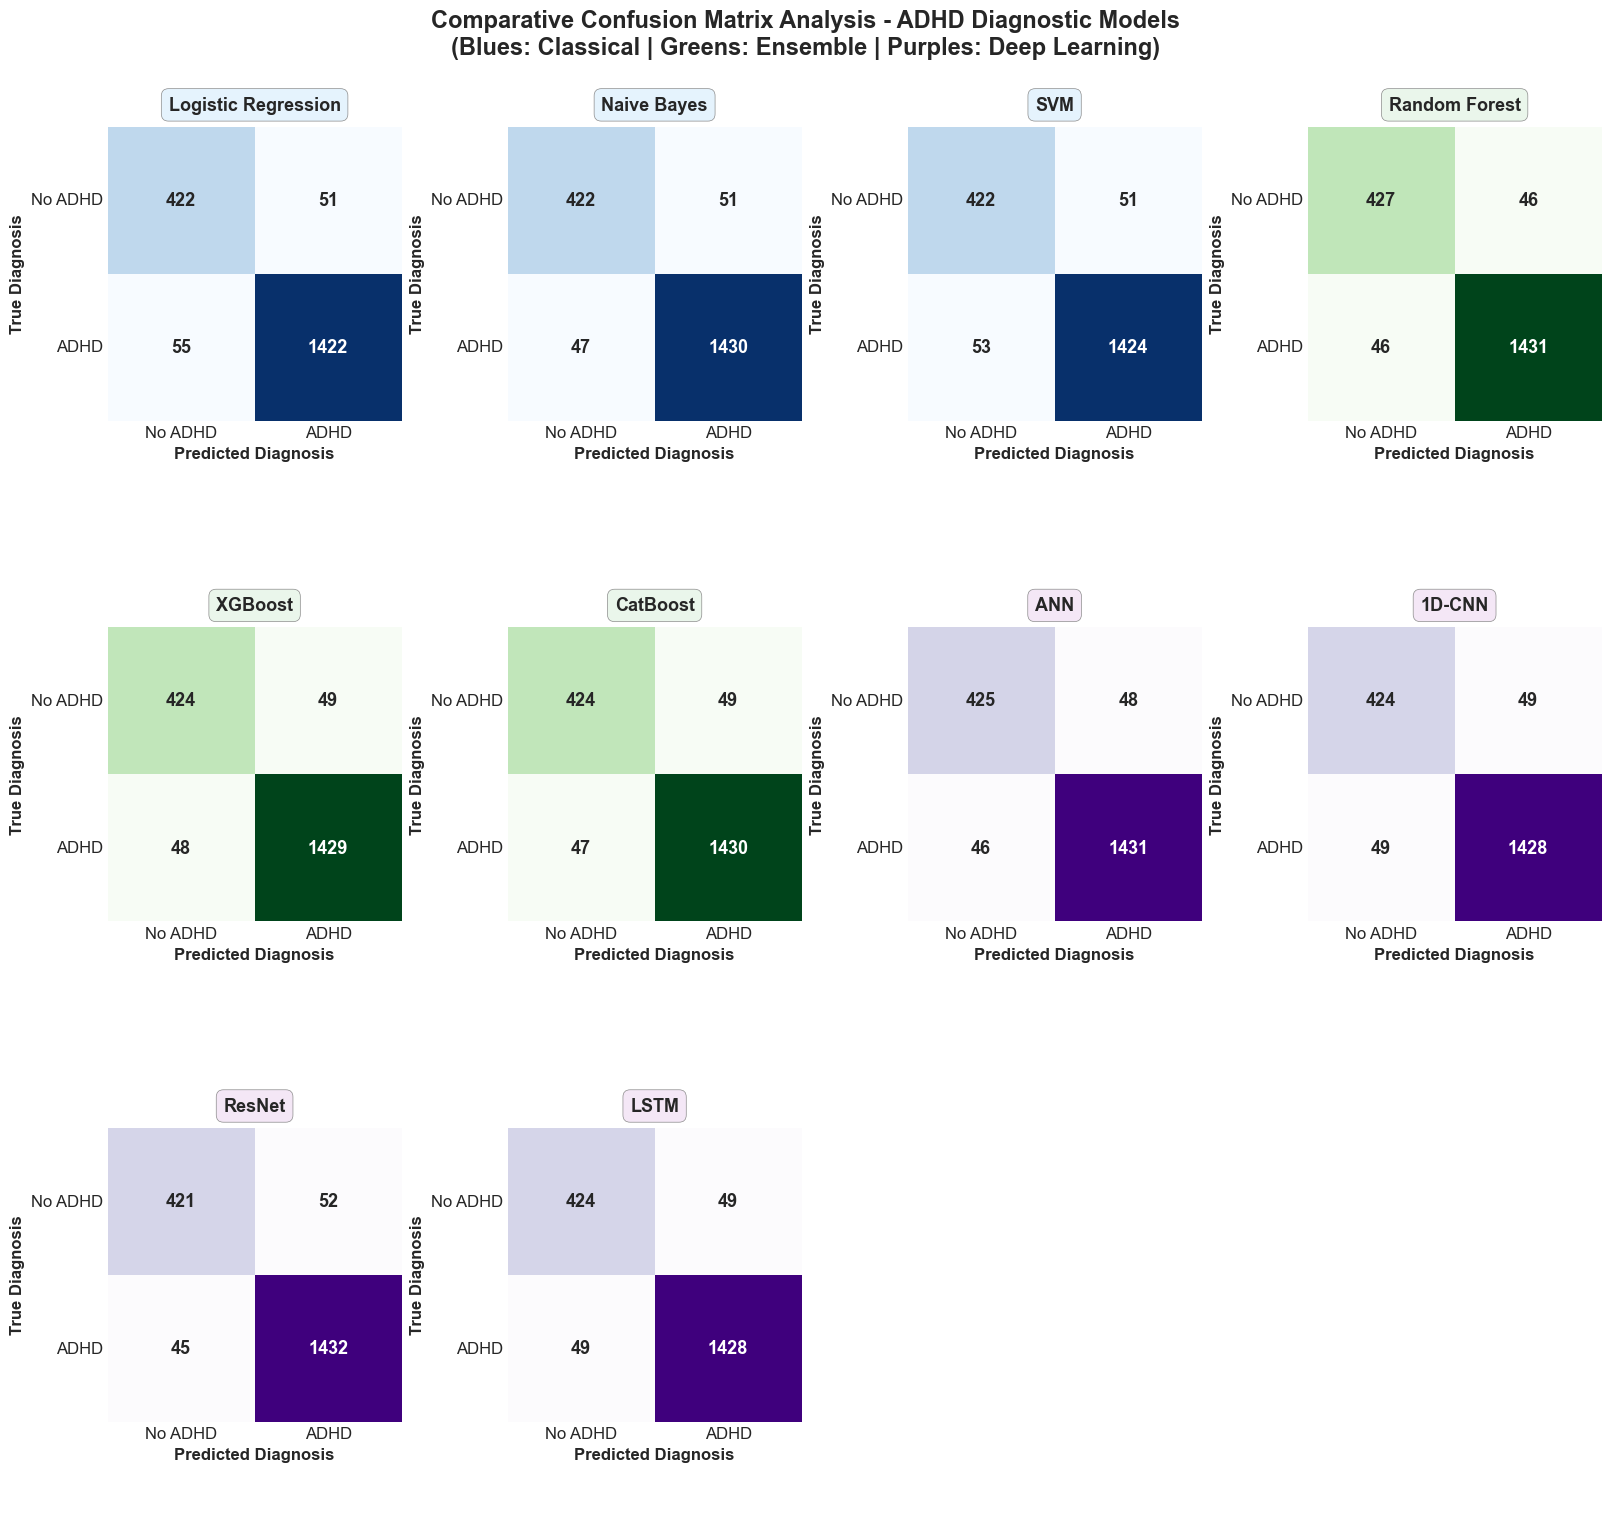

In [51]:
# =============================================================================
# CELL 18: ALL CONFUSION MATRICES - CATEGORIZED BY COLOR (FINAL 10 MODELS)
# =============================================================================

# 1. Memory Cleanup and Layout Settings
plt.close('all')

# 2. Define Final 10 Models (Only categorized models from Cell 16)
model_map_config = [
    # Classical (Blue)
    ("Logistic Regression", "best_lr_predict",  "Classical"),
    ("Naive Bayes",         "best_nb_predict",  "Classical"),
    ("SVM",                 "best_svm_predict", "Classical"),
    
    # Ensemble (Green)
    ("Random Forest",       "best_rf_predict",  "Ensemble"),
    ("XGBoost",             "best_xgb_predict", "Ensemble"),
    ("CatBoost",            "best_cat_predict", "Ensemble"),
    
    # Deep Learning (Purple)
    ("ANN",                 "best_ann_predict", "Deep Learning"),
    ("1D-CNN",              "best_cnn_predict", "Deep Learning"),
    ("ResNet",              "best_resnet_predict", "Deep Learning"),
    ("LSTM",                "best_lstm_predict", "Deep Learning")
]

# Check for active models in memory
active_models = []
for name, var_name, category in model_map_config:
    if var_name in globals():
        active_models.append((name, globals()[var_name], category))
    else:
        print(f"ℹ️ {name} skipped (Not trained yet).")

if not active_models:
    print(" ERROR: No model results found in memory.")
else:
    # 3. Dynamic Grid Setup
    num_models = len(active_models)
    cols = 4  # 4 matrices per row for better visibility
    rows = (num_models // cols) + (1 if num_models % cols > 0 else 0)
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), layout='constrained')
    axes = axes.ravel() 
    
    # 4. Color Palettes and Themes
    category_colors = {
        'Classical': 'Blues',
        'Ensemble': 'Greens', 
        'Deep Learning': 'Purples'
    }
    
    background_colors = {
        'Classical': '#E3F2FD', 
        'Ensemble': '#E8F5E9', 
        'Deep Learning': '#F3E5F5'
    }

    # 5. Drawing Loop
    for idx, (name, pred, category) in enumerate(active_models):
        y_true = y_test 
        
        # Flatten deep learning predictions if necessary
        if hasattr(pred, "ndim") and pred.ndim > 1: 
            pred = pred.flatten()
        
        cm = confusion_matrix(y_true, pred)
        
        # Heatmap plotting
        sns.heatmap(cm, annot=True, fmt='d', cmap=category_colors[category], 
                    ax=axes[idx], cbar=False, square=True, 
                    annot_kws={'size': 13, 'weight': 'bold'})
        
        # Title and Header Style
        axes[idx].set_title(f'{name}', 
                            fontsize=13, fontweight='bold', pad=12,
                            bbox=dict(boxstyle='round,pad=0.4', 
                                      facecolor=background_colors[category],
                                      edgecolor='gray',
                                      alpha=0.9))
                                      
        axes[idx].set_xlabel('Predicted Diagnosis', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('True Diagnosis', fontsize=12, fontweight='bold')
        
        # Labels: No ADHD vs ADHD
        axes[idx].set_xticklabels(['No ADHD', 'ADHD'], fontsize=12)
        axes[idx].set_yticklabels(['No ADHD', 'ADHD'], fontsize=12, rotation=0)

    # 6. Hide empty subplots
    for i in range(num_models, len(axes)):
        axes[i].axis('off')

    # 7. Final Suptitle and Save
    plt.suptitle('Comparative Confusion Matrix Analysis - ADHD Diagnostic Models\n(Blues: Classical | Greens: Ensemble | Purples: Deep Learning)', 
                 fontsize=17, fontweight='bold', y=1.01)

    try:
        plt.savefig('all_confusion_matrices_final.png', dpi=300, bbox_inches='tight')
        print("\n Final confusion matrices saved as 'all_confusion_matrices_final.png'")
    except Exception as e:
        print(f"\n Save failed: {e}")

    plt.show()


✅ Extended performance heatmap saved as 'adhd_performance_heatmap_extended.png'


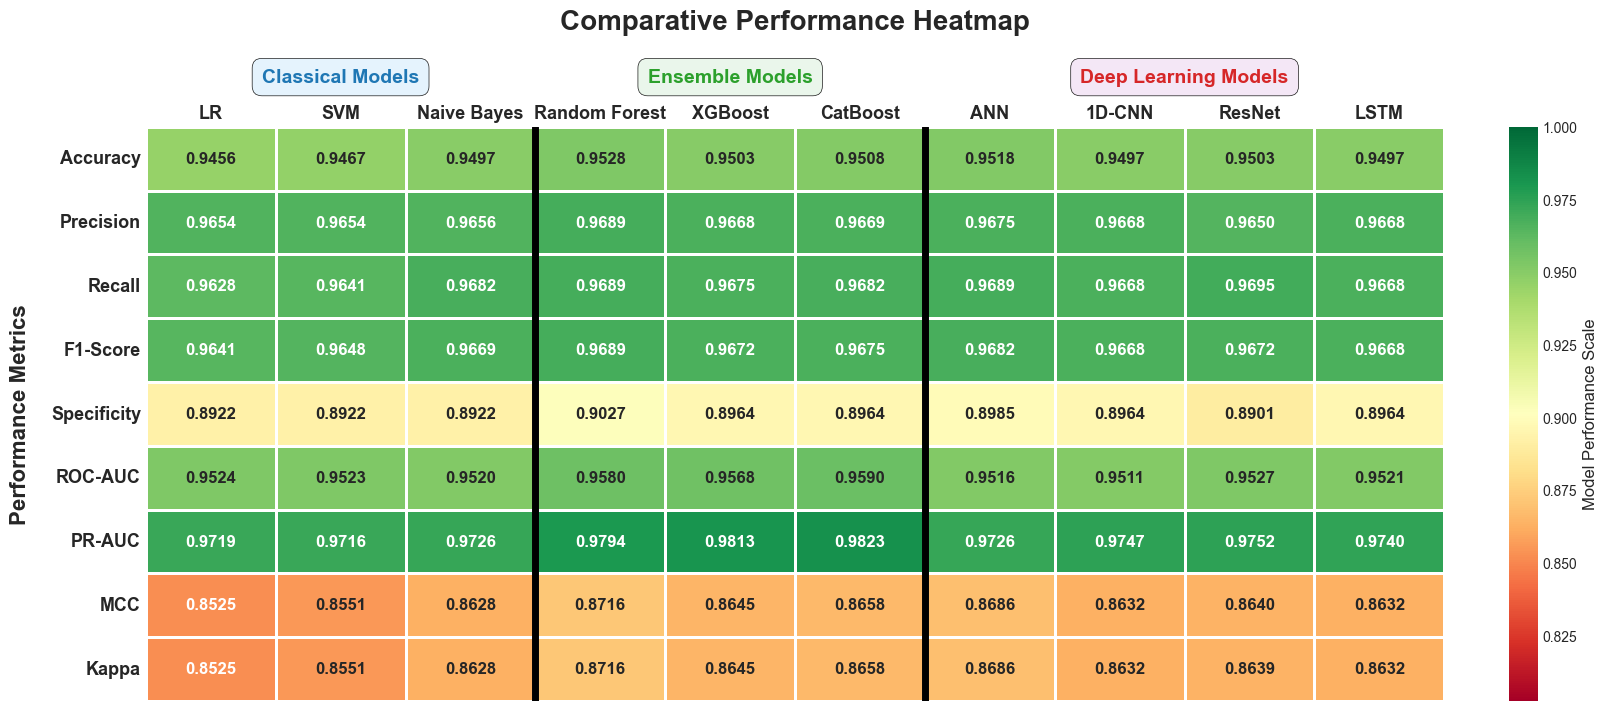

In [52]:
# =============================================================================
# PERFORMANCE HEATMAP - GROUPED BY CATEGORY (FROM model_results DICTIONARY)
# =============================================================================

# 1. Memory Cleanup
# -----------------------------------------------------------------------------
plt.close('all')

# 2. Data Validation
# -----------------------------------------------------------------------------
if 'model_results' not in globals() or len(model_results) == 0:
    print("❌ ERROR: 'model_results' dictionary not found. Please run model training cells first.")
else:
    # 3. Metric Extraction from model_results Dictionary
    # -----------------------------------------------------------------------------
    heatmap_data = {}
    cat_counts = {'Classical': 0, 'Ensemble': 0, 'Deep Learning': 0}
    
    # Metrics to extract (in order for heatmap rows)
    metrics_to_extract = [
        "Accuracy", 
        "Precision", 
        "Recall", 
        "F1_Score",
        "Specificity",
        "ROC_AUC",
        "PR_AUC",
        "MCC", 
        "Kappa"
    ]
    
    for model_name, model_data in model_results.items():
        category = model_data.get("Category", "Unknown")
        
        # Extract metrics in correct order
        metric_values = []
        for metric_key in metrics_to_extract:
            value = model_data.get(metric_key, 0.0)
            metric_values.append(value)
        
        heatmap_data[model_name] = metric_values
        
        # Count models per category
        if category in cat_counts:
            cat_counts[category] += 1
    
    # 4. Create DataFrame (Metrics as Rows, Models as Columns)
    # -----------------------------------------------------------------------------
    metric_labels = [
        "Accuracy", 
        "Precision", 
        "Recall", 
        "F1-Score",
        "Specificity",
        "ROC-AUC",
        "PR-AUC",
        "MCC", 
        "Kappa"
    ]
    
    df_heatmap = pd.DataFrame(heatmap_data, index=metric_labels)
    
    # Sort columns by category (Classical → Ensemble → Deep Learning)
    category_order = []
    for cat in ['Classical', 'Ensemble', 'Deep Learning']:
        for model_name, model_data in model_results.items():
            if model_data.get("Category") == cat and model_name not in category_order:
                category_order.append(model_name)
    
    df_heatmap = df_heatmap[category_order]
    
    # 5. Visualization (Heatmap)
    # -----------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(16, 7), layout='constrained')
    
    # Color range setting (Optimal contrast for medical data)
    min_val = df_heatmap.min().min()
    vmin_set = max(0.5, min_val - 0.05)
    
    sns.heatmap(df_heatmap, 
                annot=True, 
                fmt=".4f", 
                cmap="RdYlGn",
                linewidths=2, 
                linecolor='white',
                annot_kws={"size": 12, "weight": "bold"},
                cbar_kws={'label': 'Model Performance Scale'},
                vmin=vmin_set, vmax=1.0, 
                ax=ax)
    
    # 6. Category Separators and Labels
    # -----------------------------------------------------------------------------
    current_idx = 0
    
    # Classical Group
    if cat_counts['Classical'] > 0:
        current_idx += cat_counts['Classical']
        ax.axvline(x=current_idx, color='black', linewidth=5)
        center_pos = current_idx / 2
        ax.text(center_pos, -0.7, 'Classical Models', ha='center', fontsize=14, weight='bold', color='#1f77b4', 
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#E3F2FD', alpha=0.9, edgecolor='black'))
    
    # Ensemble Group
    if cat_counts['Ensemble'] > 0:
        prev_idx = current_idx
        current_idx += cat_counts['Ensemble']
        ax.axvline(x=current_idx, color='black', linewidth=5)
        center_pos = prev_idx + (cat_counts['Ensemble'] / 2)
        ax.text(center_pos, -0.7, 'Ensemble Models', ha='center', fontsize=14, weight='bold', color='#2ca02c', 
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#E8F5E9', alpha=0.9, edgecolor='black'))
    
    # Deep Learning Group
    if cat_counts['Deep Learning'] > 0:
        prev_idx = current_idx
        center_pos = prev_idx + (cat_counts['Deep Learning'] / 2)
        ax.text(center_pos, -0.7, 'Deep Learning Models', ha='center', fontsize=14, weight='bold', color='#d62728', 
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#F3E5F5', alpha=0.9, edgecolor='black'))
    
    # 7. Final Titles and Axes
    # -----------------------------------------------------------------------------
    plt.title("Comparative Performance Heatmap", 
              fontsize=20, pad=70, weight='bold')
    
    # Move X labels (Models) to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    plt.ylabel("Performance Metrics", fontsize=16, weight='bold', labelpad=15)
    plt.xticks(rotation=0, ha='center', fontsize=13, weight='bold')
    plt.yticks(rotation=0, fontsize=13, weight='bold')
    
    # 8. Save Report
    # -----------------------------------------------------------------------------
    try:
        plt.savefig('adhd_performance_heatmap_extended.png', dpi=300, bbox_inches='tight')
        print("\n✅ Extended performance heatmap saved as 'adhd_performance_heatmap_extended.png'")
    except Exception as e:
        print(f"⚠️ Save failed: {e}")
    
    plt.show()


 MODEL EFFICIENCY & COMPUTATIONAL COST ANALYSIS - ADHD PROJECT

Table 5. Detailed Time Cost Analysis of Algorithms

        Model      Category  CV & Tuning Time (s)  Final Training Time (s)  Total Dev. Time (s)  Inference Time (ms)
           LR     Classical                3.9983                   0.0058               4.2944               0.1489
          SVM     Classical               75.3227                  17.7407              93.3876               0.1662
  Naive Bayes     Classical                0.1338                   0.0018               0.6698               0.2740
      XGBoost      Ensemble                6.7035                   0.0468               7.7561               0.5158
     CatBoost      Ensemble               41.8993                   0.6892              43.7403               0.5906
          ANN Deep Learning               35.4605                   7.7599             120.5183              39.6399
       1D-CNN Deep Learning               35.7415               

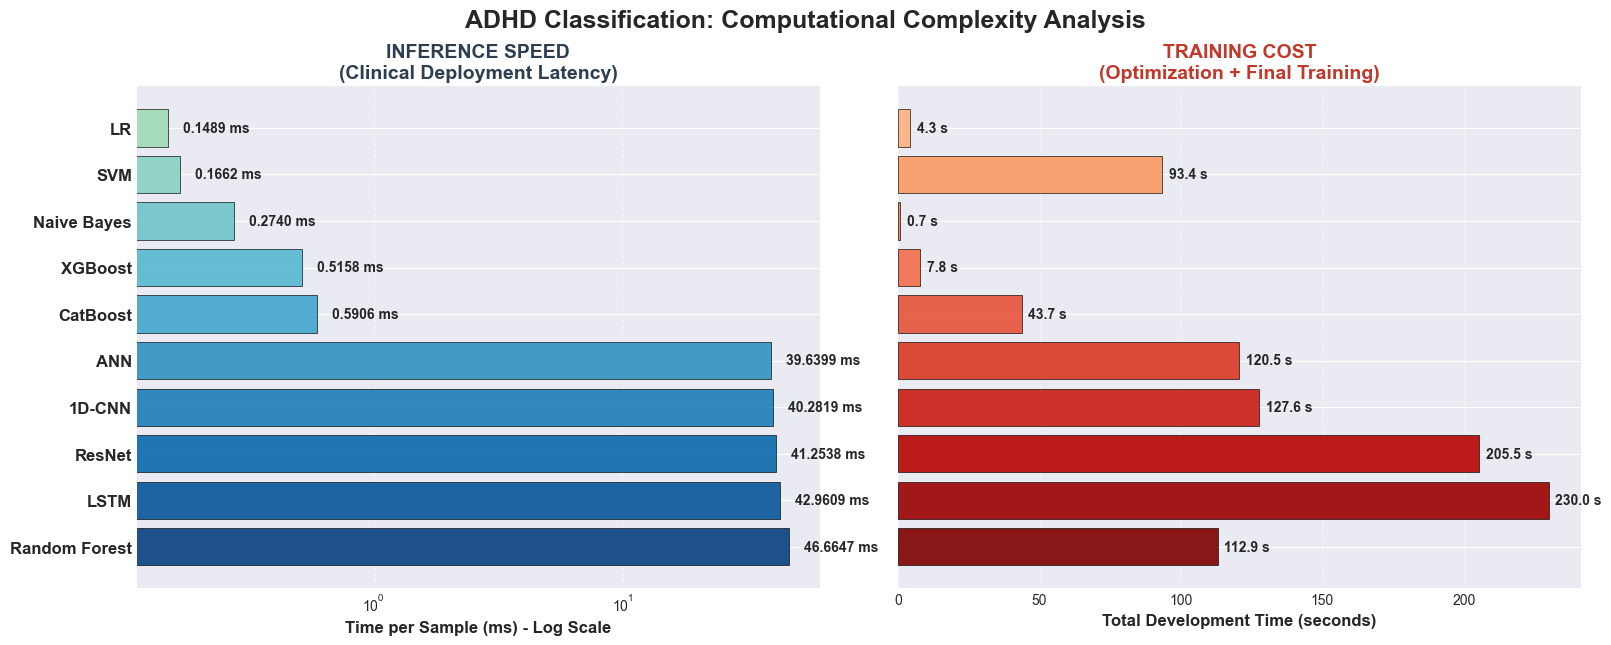

In [53]:
# =============================================================================
# CELL 20: COMPREHENSIVE TIMING ANALYSIS (FINAL 10 MODELS - DETAILED)
# =============================================================================

print("\n" + "=" * 115)
print(" MODEL EFFICIENCY & COMPUTATIONAL COST ANALYSIS - ADHD PROJECT")
print("=" * 115)

# 1. Final 10 Models Categories
model_categories = {
    'LR': 'Classical',
    'Naive Bayes': 'Classical',
    'SVM': 'Classical',
    'Random Forest': 'Ensemble',
    'XGBoost': 'Ensemble',
    'CatBoost': 'Ensemble',
    'ANN': 'Deep Learning',
    '1D-CNN': 'Deep Learning',
    'ResNet': 'Deep Learning',
    'LSTM': 'Deep Learning'
}

# 2. Data Preparation from 'model_time_results' (NEW GLOBAL STRUCTURE)
# -----------------------------------------------------------------------------
if 'model_time_results' in globals() and model_time_results:
    timing_data = []

    for model_name, results in model_time_results.items():
        # Handle model naming differences (e.g. 'Logistic Regression' vs 'LR')
        category = model_categories.get(model_name, 'Unknown')
        
        # Extract data from the new structure
        cv_tuning = results.get('CV_Time', 0)
        final_train = results.get('Training_Time', 0)
        total_dev = results.get('Total_Time', 0)
        inf_speed = results.get('Latency_ms', 0) # Using Latency per sample (ms)
        
        timing_data.append({
            'Model': model_name,
            'Category': category,
            'CV & Tuning Time (s)': cv_tuning,
            'Final Training Time (s)': final_train,
            'Total Dev. Time (s)': total_dev,
            'Inference Time (ms)': inf_speed
        })

    timing_df = pd.DataFrame(timing_data)
    
    # Sorting: Inference Time (ms) - Fastest to Slowest
    timing_df = timing_df.sort_values('Inference Time (ms)', ascending=True).reset_index(drop=True)

    # Print Table in Academic Format
    print("\nTable 5. Detailed Time Cost Analysis of Algorithms\n")
    print(timing_df.round(4).to_string(index=False))

    # -------------------------------------------------------------------------
    # STATISTICAL SUMMARY
    # -------------------------------------------------------------------------
    print("\n" + "-" * 115)
    print(" EFFICIENCY SUMMARY")
    if not timing_df.empty:
        fastest_inf = timing_df.iloc[0]
        slowest_inf = timing_df.iloc[-1]
        print(f"🚀 Most Efficient (Inference): {fastest_inf['Model']} ({fastest_inf['Inference Time (ms)']:.4f} ms)")
        print(f"🐢 Least Efficient (Inference): {slowest_inf['Model']} ({slowest_inf['Inference Time (ms)']:.4f} ms)")
    print("-" * 115)

    # -------------------------------------------------------------------------
    # VISUALIZATION (1 IMAGE, 2 COLUMNS)
    # -------------------------------------------------------------------------
    plt.close('all') 
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), layout='constrained')
    
    models = timing_df['Model'].values
    y_pos = np.arange(len(models))
    
    # --- LEFT PLOT: INFERENCE TIME (Log Scale) ---
    inf_times = timing_df['Inference Time (ms)'].values
    colors_inf = plt.cm.GnBu(np.linspace(0.4, 1, len(models)))
    
    axes[0].barh(y_pos, inf_times, color=colors_inf, edgecolor='black', alpha=0.9)
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(models, fontsize=12, fontweight='bold')
    axes[0].invert_yaxis() 
    axes[0].set_xlabel('Time per Sample (ms) - Log Scale', fontsize=12, fontweight='bold')
    axes[0].set_title('INFERENCE SPEED\n(Clinical Deployment Latency)', fontsize=14, fontweight='bold', color='#2c3e50')
    axes[0].set_xscale('log') 
    axes[0].grid(axis='x', linestyle='--', alpha=0.5)
    
    for i, v in enumerate(inf_times):
        # Dynamic label positioning for log scale
        axes[0].text(v * 1.15, i, f"{v:.4f} ms", va='center', fontweight='bold', fontsize=10)

    # --- RIGHT PLOT: TOTAL DEVELOPMENT TIME (Linear Scale) ---
    train_times = timing_df['Total Dev. Time (s)'].values
    colors_train = plt.cm.OrRd(np.linspace(0.4, 1, len(models)))
    
    axes[1].barh(y_pos, train_times, color=colors_train, edgecolor='black', alpha=0.9)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels([]) # Hidden as it shares y-axis
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Total Development Time (seconds)', fontsize=12, fontweight='bold')
    axes[1].set_title('TRAINING COST\n(Optimization + Final Training)', fontsize=14, fontweight='bold', color='#c0392b')
    axes[1].grid(axis='x', linestyle='--', alpha=0.5)
    
    for i, v in enumerate(train_times):
        axes[1].text(v + (max(train_times)*0.01), i, f"{v:.1f} s", va='center', fontweight='bold', fontsize=10)

    plt.suptitle('ADHD Classification: Computational Complexity Analysis', fontsize=18, fontweight='bold', y=1.05)
    
    try:
        plt.savefig('adhd_detailed_timing_analysis.png', dpi=300, bbox_inches='tight')
        print("\n Visualization saved as 'adhd_detailed_timing_analysis.png'")
    except Exception as e:
        print(f"\n Save failed: {e}")

    plt.show()

    # -------------------------------------------------------------------------
    # EXPORTS
    # -------------------------------------------------------------------------
    timing_df.to_csv('adhd_detailed_timing_report.csv', index=False)

else:
    print(" 'model_time_results' dictionary not found. Please run individual model cells first.")


 OVERFITTING ANALYSIS (GENERALIZATION GAP ASSESSMENT)
 Calculating Train vs Test Accuracy for generalization analysis...


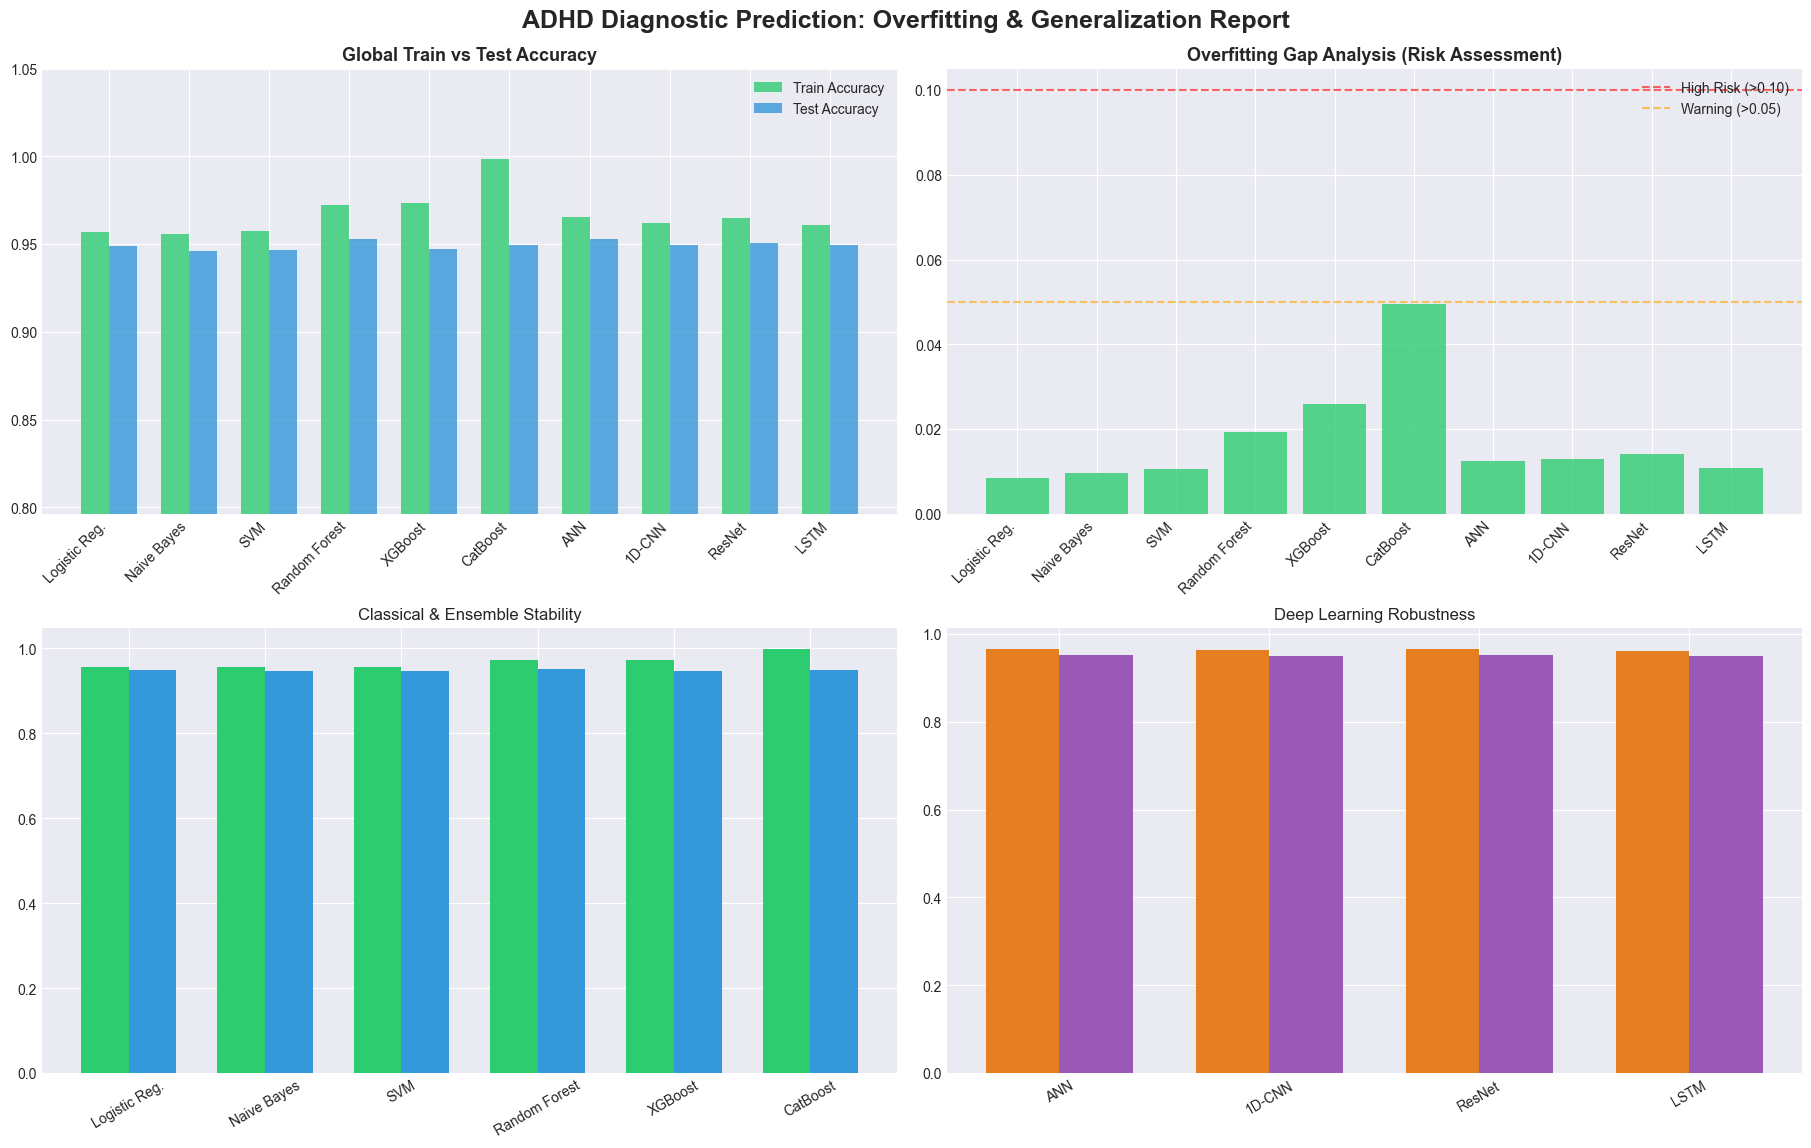


 DETAILED OVERFITTING RISK REPORT
        Model      Category  Train Acc  Test Acc      Gap    Status
Logistic Reg.     Classical   0.957143  0.948718 0.008425 ✅ OPTIMAL
  Naive Bayes     Classical   0.955824  0.946154 0.009670 ✅ OPTIMAL
          SVM     Classical   0.957363  0.946667 0.010696 ✅ OPTIMAL
Random Forest      Ensemble   0.972088  0.952821 0.019267 ✅ OPTIMAL
      XGBoost      Ensemble   0.973187  0.947179 0.026007 ✅ OPTIMAL
     CatBoost      Ensemble   0.998681  0.949231 0.049451 ✅ OPTIMAL
          ANN Deep Learning   0.965275  0.952821 0.012454 ✅ OPTIMAL
       1D-CNN Deep Learning   0.962198  0.949231 0.012967 ✅ OPTIMAL
       ResNet Deep Learning   0.964835  0.950769 0.014066 ✅ OPTIMAL
         LSTM Deep Learning   0.960659  0.949744 0.010916 ✅ OPTIMAL

📈 CATEGORY-WISE OVERFITTING SUMMARY

CLASSICAL & ENSEMBLE MODELS (6 models):
  Average Gap: 0.0206
  Max Gap:     0.0495 (CatBoost)
  Min Gap:     0.0084 (Logistic Reg.)

DEEP LEARNING MODELS (4 models):
  Average Ga

In [54]:
# =============================================================================
# CELL 21: OVERFITTING ANALYSIS (TRAIN vs TEST ACCURACY COMPARISON)
# =============================================================================

print("\n" + "=" * 100)
print(" OVERFITTING ANALYSIS (GENERALIZATION GAP ASSESSMENT)")
print("=" * 100)

model_configs = [
    # --- Classical Models (Input: 2D X_train) ---
    ("Logistic Reg.", "best_lr", X_train, y_train, X_test, y_test, "Classical"),
    ("Naive Bayes",   "best_nb", X_train, y_train, X_test, y_test, "Classical"),
    ("SVM",           "best_svm", X_train, y_train, X_test, y_test, "Classical"),
    
    # --- Ensemble Models (Input: 2D X_train) ---
    ("Random Forest", "best_rf", X_train, y_train, X_test, y_test, "Ensemble"),
    ("XGBoost",       "best_xgb", X_train, y_train, X_test, y_test, "Ensemble"),
    ("CatBoost",      "best_cat", X_train, y_train, X_test, y_test, "Ensemble"),
    
    # --- Deep Learning Models ---
    #  ANN: Should use 2-dimensional data (X_train),  CNN/ResNet/LSTM: Should use 3-dimensional data (X_train_dl)
    ("ANN",           "ann_model",    X_train,    y_train, X_test,    y_test, "Deep Learning"),
    # 
    ("1D-CNN",        "cnn_model",    X_train_dl, y_train, X_test_dl, y_test, "Deep Learning"),
    ("ResNet",        "resnet_model", X_train_dl, y_train, X_test_dl, y_test, "Deep Learning"),
    ("LSTM",          "lstm_model",   X_train_dl, y_train, X_test_dl, y_test, "Deep Learning")
]

results_data = []
print(" Calculating Train vs Test Accuracy for generalization analysis...")

for name, model_var, xtr, ytr, xte, yte, category in model_configs:
    if model_var in globals():
        model = globals()[model_var]
        
        try:
            # Deep Learning Models
            if category == "Deep Learning":
                xtr_arr = np.array(xtr)
                xte_arr = np.array(xte)
                
                if name == "ANN" and len(xtr_arr.shape) == 3:
                    xtr_arr = xtr_arr.reshape(xtr_arr.shape[0], -1)
                    xte_arr = xte_arr.reshape(xte_arr.shape[0], -1)

                train_probs = model.predict(xtr_arr, verbose=0)
                train_preds = (train_probs > 0.5).astype(int).flatten()
                
                test_probs = model.predict(xte_arr, verbose=0)
                test_preds = (test_probs > 0.5).astype(int).flatten()
            
            # Classical Models
            else:
                train_preds = model.predict(xtr)
                test_preds = model.predict(xte)
                
            acc_train = accuracy_score(ytr, train_preds)
            acc_test = accuracy_score(yte, test_preds)
            gap = acc_train - acc_test
            
            results_data.append({
                'Model': name,
                'Category': category,
                'Train Acc': acc_train,
                'Test Acc': acc_test,
                'Gap': gap
            })
            
        except Exception as e:
            print(f" Error evaluating {name}: {str(e)}")
            
    else:
        print(f" Warning: Model '{name}' ({model_var}) not found. Skipping...")

df_overfit = pd.DataFrame(results_data)

if not df_overfit.empty:
    # --- VISUALIZATION ---
    plt.close('all')
    fig = plt.figure(figsize=(18, 11), layout='constrained')

    # Subplot 1: Train vs Test
    ax1 = plt.subplot(2, 2, 1)
    x = np.arange(len(df_overfit))
    width = 0.35
    ax1.bar(x - width/2, df_overfit['Train Acc'], width, label='Train Accuracy', color='#2ecc71', alpha=0.8)
    ax1.bar(x + width/2, df_overfit['Test Acc'], width, label='Test Accuracy', color='#3498db', alpha=0.8)
    ax1.set_title('Global Train vs Test Accuracy', fontsize=13, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_overfit['Model'], rotation=45, ha='right')
    ax1.set_ylim([max(0, df_overfit['Test Acc'].min() - 0.15), 1.05])
    ax1.legend()

    # Subplot 2: Gap Analysis
    ax2 = plt.subplot(2, 2, 2)
    gap_colors = ['#e74c3c' if g > 0.10 else '#f39c12' if g > 0.05 else '#2ecc71' for g in df_overfit['Gap']]
    ax2.bar(df_overfit['Model'], df_overfit['Gap'], color=gap_colors, alpha=0.8)
    ax2.set_title('Overfitting Gap Analysis (Risk Assessment)', fontsize=13, fontweight='bold')
    ax2.axhline(y=0.10, color='red', linestyle='--', alpha=0.6, label='High Risk (>0.10)')
    ax2.axhline(y=0.05, color='orange', linestyle='--', alpha=0.6, label='Warning (>0.05)')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax2.legend()

    # Subplot 3 & 4
    ax3 = plt.subplot(2, 2, 3)
    df_ce = df_overfit[df_overfit['Category'] != 'Deep Learning']
    if not df_ce.empty:
        ax3.bar(np.arange(len(df_ce)) - width/2, df_ce['Train Acc'], width, color='#2ecc71')
        ax3.bar(np.arange(len(df_ce)) + width/2, df_ce['Test Acc'], width, color='#3498db')
        ax3.set_title('Classical & Ensemble Stability', fontsize=12)
        ax3.set_xticks(np.arange(len(df_ce)))
        ax3.set_xticklabels(df_ce['Model'], rotation=30)

    ax4 = plt.subplot(2, 2, 4)
    df_dl = df_overfit[df_overfit['Category'] == 'Deep Learning']
    if not df_dl.empty:
        ax4.bar(np.arange(len(df_dl)) - width/2, df_dl['Train Acc'], width, color='#e67e22')
        ax4.bar(np.arange(len(df_dl)) + width/2, df_dl['Test Acc'], width, color='#9b59b6')
        ax4.set_title('Deep Learning Robustness', fontsize=12)
        ax4.set_xticks(np.arange(len(df_dl)))
        ax4.set_xticklabels(df_dl['Model'], rotation=30)

    plt.suptitle('ADHD Diagnostic Prediction: Overfitting & Generalization Report', fontsize=18, fontweight='bold', y=1.03)
    plt.savefig('comprehensive_overfitting_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- TEXT REPORT ---
    print("\n" + "=" * 100)
    print(" DETAILED OVERFITTING RISK REPORT")
    print("=" * 100)
    df_overfit['Status'] = df_overfit['Gap'].apply(lambda x: "🚨 HIGH OVERFIT" if x > 0.10 else ("⚠️ MODERATE" if x > 0.05 else ("✅ OPTIMAL")))
    print(df_overfit[['Model', 'Category', 'Train Acc', 'Test Acc', 'Gap', 'Status']].to_string(index=False))

    # --- CATEGORY SUMMARY ---
    print("\n" + "=" * 100)
    print("📈 CATEGORY-WISE OVERFITTING SUMMARY")
    print("=" * 100)
    
    for cat_name in ['Classical', 'Ensemble', 'Deep Learning']:
        if cat_name == 'Classical': 
             cat_df = df_overfit[df_overfit['Category'].isin(['Classical', 'Ensemble'])]
             label = "CLASSICAL & ENSEMBLE MODELS"
        elif cat_name == 'Deep Learning':
             cat_df = df_overfit[df_overfit['Category'] == 'Deep Learning']
             label = "DEEP LEARNING MODELS"
        else: continue

        print(f"\n{label} ({len(cat_df)} models):")
        if not cat_df.empty:
            print(f"  Average Gap: {cat_df['Gap'].mean():.4f}")
            print(f"  Max Gap:     {cat_df['Gap'].max():.4f} ({cat_df.loc[cat_df['Gap'].idxmax(), 'Model']})")
            print(f"  Min Gap:     {cat_df['Gap'].min():.4f} ({cat_df.loc[cat_df['Gap'].idxmin(), 'Model']})")
        else:
            print("  No models found in this category.")
else:
    print(" No model data available.")

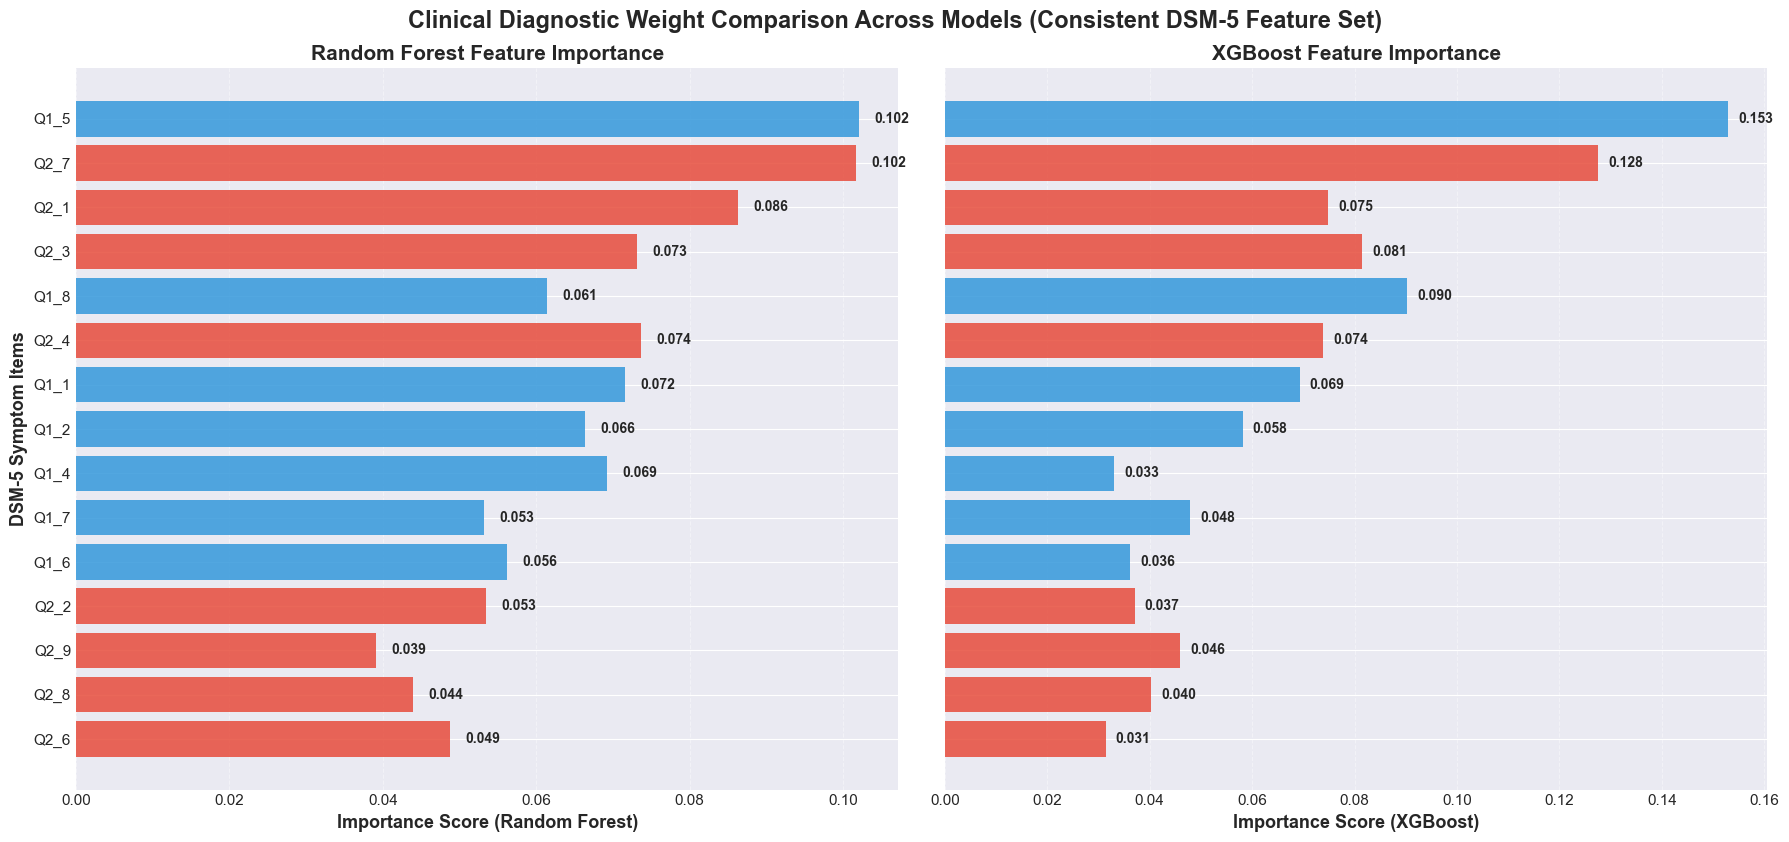


Feature importance charts generated successfully.


In [58]:
# ====================================================================================
# CELL 22: CLINICAL INTERPRETATION - FEATURE IMPORTANCE (RF & XGBOOST SIDE-BY-SIDE)
# ====================================================================================

# Model control
if not ('best_xgb' in globals() and 'best_rf' in globals()):
    print(" Both best_xgb and best_rf models must be trained first.")
else:
    feature_names = SELECTED_FEATURES

    # Importance scores
    rf_importance  = best_rf.feature_importances_
    xgb_importance = best_xgb.feature_importances_

    # Creating a DataFrame
    df = pd.DataFrame({
        'Feature': feature_names,
        'RandomForest': rf_importance,
        'XGBoost': xgb_importance
    })

    # Sorting by average importance
    df['Mean'] = df[['RandomForest', 'XGBoost']].mean(axis=1)
    df = df.sort_values('Mean', ascending=True)

    # Clinical color coding (Q1: Inattention, Q2: Hyperactivity)
    colors = ['#3498db' if f.startswith('Q1') else '#e74c3c' for f in df['Feature']]

    # Side-by-side plots (RF first)
    fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharey=True)

    # =========================
    # RANDOM FOREST (LEFT)
    # =========================
    axes[0].barh(df['Feature'], df['RandomForest'], color=colors, alpha=0.85)
    axes[0].set_title('Random Forest Feature Importance', fontsize=15, fontweight='bold')
    axes[0].set_xlabel('Importance Score (Random Forest)', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('DSM-5 Symptom Items', fontsize=13, fontweight='bold')
    axes[0].tick_params(axis='both', labelsize=11)
    axes[0].grid(axis='x', linestyle='--', alpha=0.4)

    for i, v in enumerate(df['RandomForest']):
        axes[0].text(v + 0.002, i, f"{v:.3f}",
                     va='center', fontsize=10, fontweight='bold')

    # =========================
    # XGBOOST (RIGHT)
    # =========================
    axes[1].barh(df['Feature'], df['XGBoost'], color=colors, alpha=0.85)
    axes[1].set_title('XGBoost Feature Importance', fontsize=15, fontweight='bold')
    axes[1].set_xlabel('Importance Score (XGBoost)', fontsize=13, fontweight='bold')
    axes[1].tick_params(axis='both', labelsize=11)
    axes[1].grid(axis='x', linestyle='--', alpha=0.4)

    for i, v in enumerate(df['XGBoost']):
        axes[1].text(v + 0.002, i, f"{v:.3f}",
                     va='center', fontsize=10, fontweight='bold')

    fig.suptitle(
        'Clinical Diagnostic Weight Comparison Across Models (Consistent DSM-5 Feature Set)',
        fontsize=17,
        fontweight='bold',
        y=0.93
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('RF_XGB_Feature_Importance_SideBySide.png', dpi=300)
    plt.show()

    print("\nFeature importance charts generated successfully.")